In [45]:
import uproot as ur
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import awkward as ak
import mplhep as hep
hep.style.use("CMS")
hep.style.use(hep.style.CMS)

In [48]:
data_directory = "/media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_rhodecay_log10continuous_1GeV-150GeV_2.3deg-4.25deg_08_21_2025/"
file_name = "reco_rhodecay_log10continuous_1GeV-150GeV_theta_2.3deg-4.25deg_99.edm4hep.root"
with ur.open("{file}:events".format(file=data_directory+file_name)) as events:
    MC = events.arrays(["MCParticles.generatorStatus", "MCParticles.PDG",'MCParticles.mass',
                            'MCParticles.momentum.x', 'MCParticles.momentum.y', 'MCParticles.momentum.z', 'MCParticles.endpoint.z', 
                            'MCParticles.vertex.x', 'MCParticles.vertex.y', 'MCParticles.vertex.z'])
    reco = events.arrays(["EcalEndcapPRecHits.energy", "EcalEndcapPRecHits.time", "EcalEndcapPRecHits.position.x", "EcalEndcapPRecHits.position.y", "EcalEndcapPRecHits.position.z",
                          "EcalEndcapPInsertRecHits.energy", "EcalEndcapPInsertRecHits.time", "EcalEndcapPInsertRecHits.position.x", "EcalEndcapPInsertRecHits.position.y", "EcalEndcapPInsertRecHits.position.z",
                          "HcalEndcapPInsertRecHits.energy", "HcalEndcapPInsertRecHits.time", "HcalEndcapPInsertRecHits.position.x", "HcalEndcapPInsertRecHits.position.y", "HcalEndcapPInsertRecHits.position.z",
                          "LFHCALRecHits.energy", "LFHCALRecHits.time", "LFHCALRecHits.position.x", "LFHCALRecHits.position.y", "LFHCALRecHits.position.z"])
    print("Number of events:",events.num_entries)

Number of events: 5000


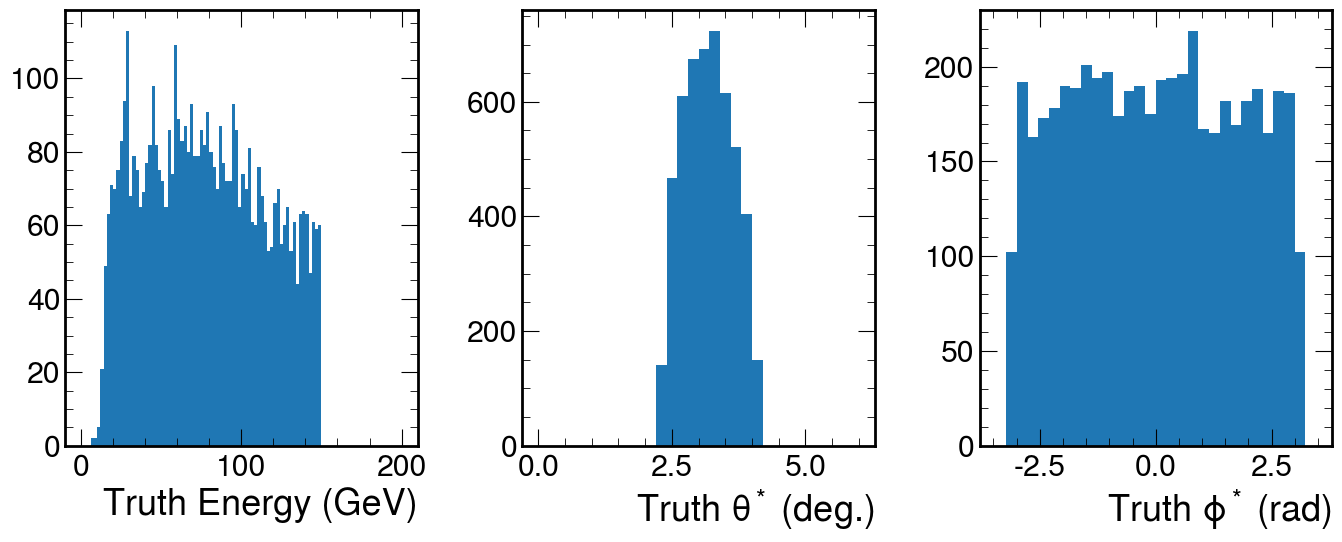

In [49]:
def rotateY(xdata, zdata, angle):
    s = np.sin(angle)
    c = np.cos(angle)
    rotatedz = c*zdata - s*xdata
    rotatedx = s*zdata + c*xdata
    return rotatedx, rotatedz

# Mask to get incident final state information
final_state_mask = (MC["MCParticles.generatorStatus"]==2) & (MC["MCParticles.PDG"]==113)
# Getting the momentum in different directions and mass of the final states
px = MC["MCParticles.momentum.x"][final_state_mask]
py = MC["MCParticles.momentum.y"][final_state_mask]
pz = MC["MCParticles.momentum.z"][final_state_mask]
mass = MC["MCParticles.mass"][final_state_mask]

px, pz = rotateY(px, pz, .025)


# Calculating the neutron's energy and the angles it was fired at
momentum = np.sqrt(px**2 + py**2 + pz**2)
energy = np.sqrt(momentum**2 + mass**2) # Units = GeV
rho_energy  = energy
theta = np.arccos(pz/momentum) # Units = radians
phi = np.arctan2(py, px) # Units = radians

# Plotting the neutron energy & angles
fig, ((ax1, ax2, ax3)) = plt.subplots(1, 3, figsize=(14,6))

ax1.hist(ak.flatten(momentum), bins = 100, range = [0, 200], histtype='stepfilled')
ax1.set_xlabel("Truth Energy (GeV)")
ax2.hist(ak.flatten(theta)*180/np.pi, bins = 30, range=[0, 6], histtype='stepfilled')
ax2.set_xlabel("Truth $\\theta^*$ (deg.)")

ax3.hist(ak.flatten(phi), bins = 30, range=[-1.1*np.pi, 1.1*np.pi], histtype='stepfilled')
ax3.set_xlabel("Truth $\phi^*$ (rad)")

plt.tight_layout()

Text(1, 0, 'Gen. $\\pi^-$ $\\theta$ (rad)')

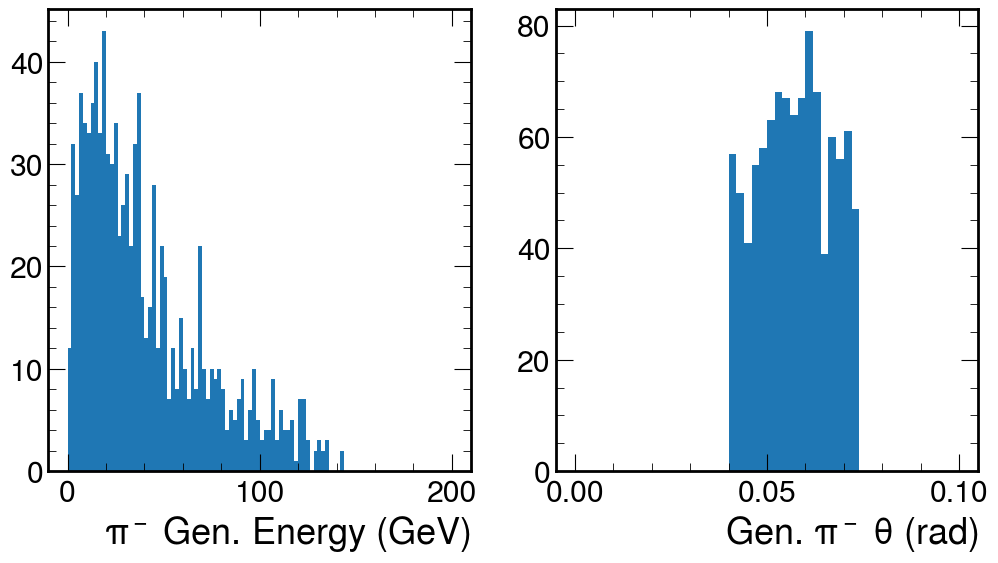

In [40]:
piplus_mask = (MC["MCParticles.PDG"]==211) & (MC["MCParticles.generatorStatus"]==1)

piplus_px = MC["MCParticles.momentum.x"][piplus_mask]
piplus_py = MC["MCParticles.momentum.y"][piplus_mask]
piplus_pz = MC["MCParticles.momentum.z"][piplus_mask]
piplus_mass = MC["MCParticles.mass"][piplus_mask]
piplus_px, piplus_pz = rotateY(piplus_px, piplus_pz, .025)

# Calculating piplus energy and angle
piplus_mom = np.sqrt(piplus_px**2 + piplus_py**2 + piplus_pz**2)
piplus_energy = np.sqrt(piplus_mom**2 + piplus_mass**2)
piplus_theta = np.arccos(piplus_pz/piplus_mom)
piplus_theta_deg = np.degrees(piplus_theta)

fig, ((ax1, ax2)) = plt.subplots(1,2, figsize=(12,6))

ax1.hist(ak.flatten(piplus_energy), bins = 100, range = [0, 200], histtype='stepfilled')
ax1.set_xlabel("$\pi^-$ Gen. Energy (GeV)")

ax2.hist(np.asarray(ak.flatten(piplus_theta)), bins=50, range=[0, .1], histtype='stepfilled')
ax2.set_xlabel('Gen. $\pi^-$ $\\theta$ (rad)')

Text(1, 0, 'Gen. $\\pi^+$ $\\theta$ (rad)')

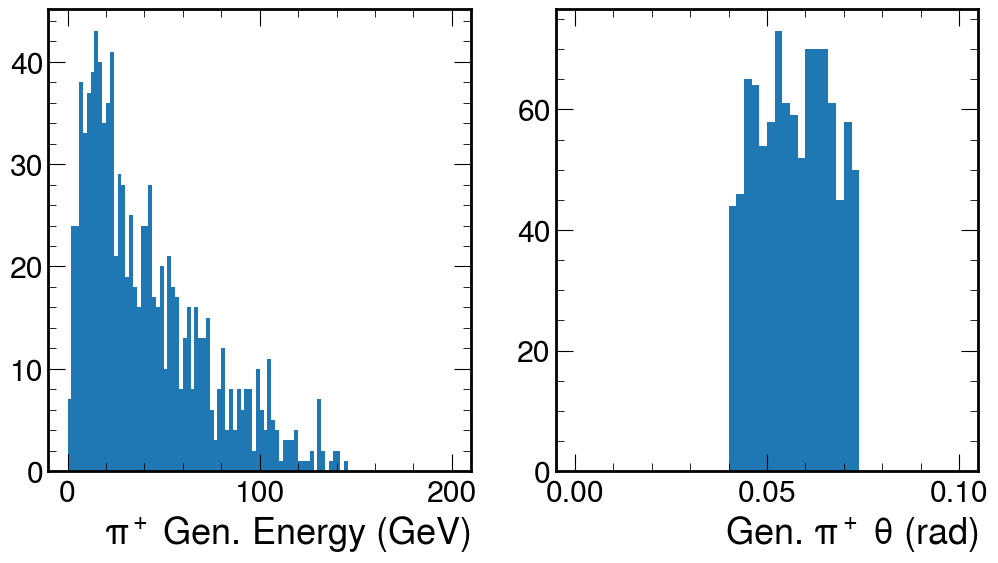

In [38]:
piminus_mask = (MC["MCParticles.PDG"]==-211) & (MC["MCParticles.generatorStatus"]==1)

piminus_px = MC["MCParticles.momentum.x"][piminus_mask]
piminus_py = MC["MCParticles.momentum.y"][piminus_mask]
piminus_pz = MC["MCParticles.momentum.z"][piminus_mask]
piminus_mass = MC["MCParticles.mass"][piminus_mask]
piminus_px, piminus_pz = rotateY(piminus_px, piminus_pz, .025)
# Calculating piminus energy and angle
piminus_mom = np.sqrt(piminus_px**2 + piminus_py**2 + piminus_pz**2)
piminus_energy = np.sqrt(piminus_mom**2 + piminus_mass**2)
piminus_theta = np.arccos(piminus_pz/piminus_mom)
piminus_theta_deg = np.degrees(piminus_theta)

fig, ((ax1, ax2)) = plt.subplots(1,2, figsize=(12,6))

ax1.hist(ak.flatten(piminus_energy), bins = 100, range = [0, 200], histtype='stepfilled')
ax1.set_xlabel("$\pi^+$ Gen. Energy (GeV)")

ax2.hist(np.asarray(ak.flatten(piminus_theta)), bins=50, range=[0, .1], histtype='stepfilled')
ax2.set_xlabel('Gen. $\pi^+$ $\\theta$ (rad)')

Text(0, 1, '$\\pi^+ + \\pi^-$ gen. E (GeV)')

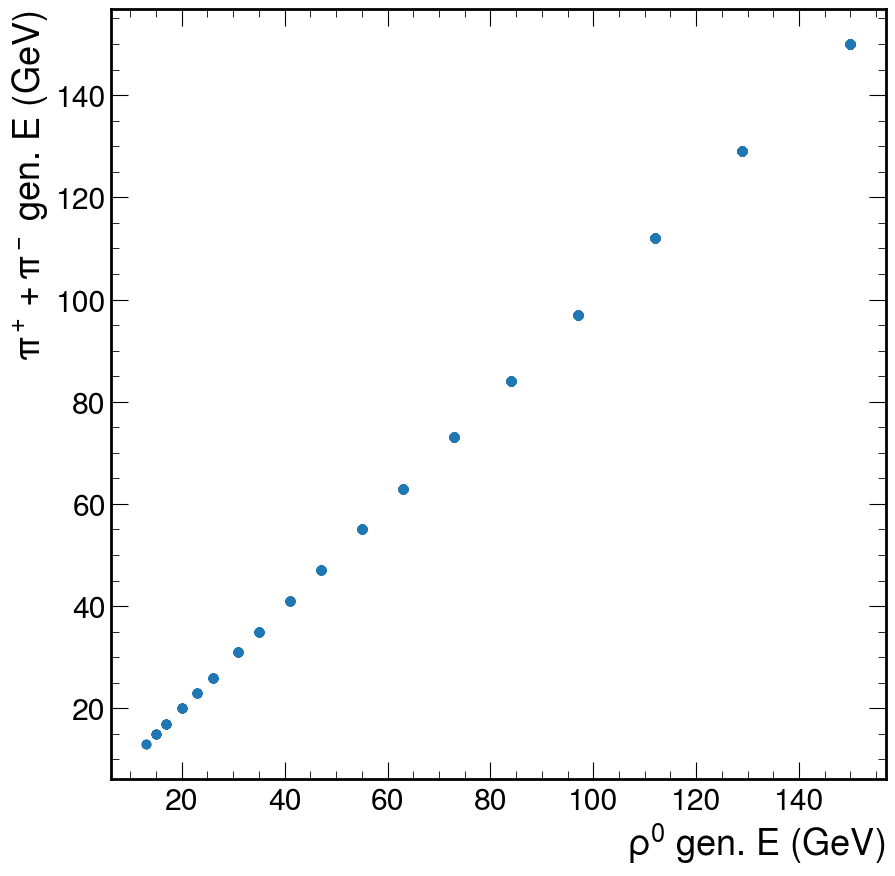

In [7]:
# Summing neutron and pi0 energies
pion_energy = ak.flatten(piplus_energy) + ak.flatten(piminus_energy)

plt.scatter(ak.flatten(rho_energy), pion_energy)
plt.xlabel("$\\rho^0$ gen. E (GeV)")
plt.ylabel("$\pi^+ + \pi^-$ gen. E (GeV)")

Text(0.5, 1.0, 'Insert')

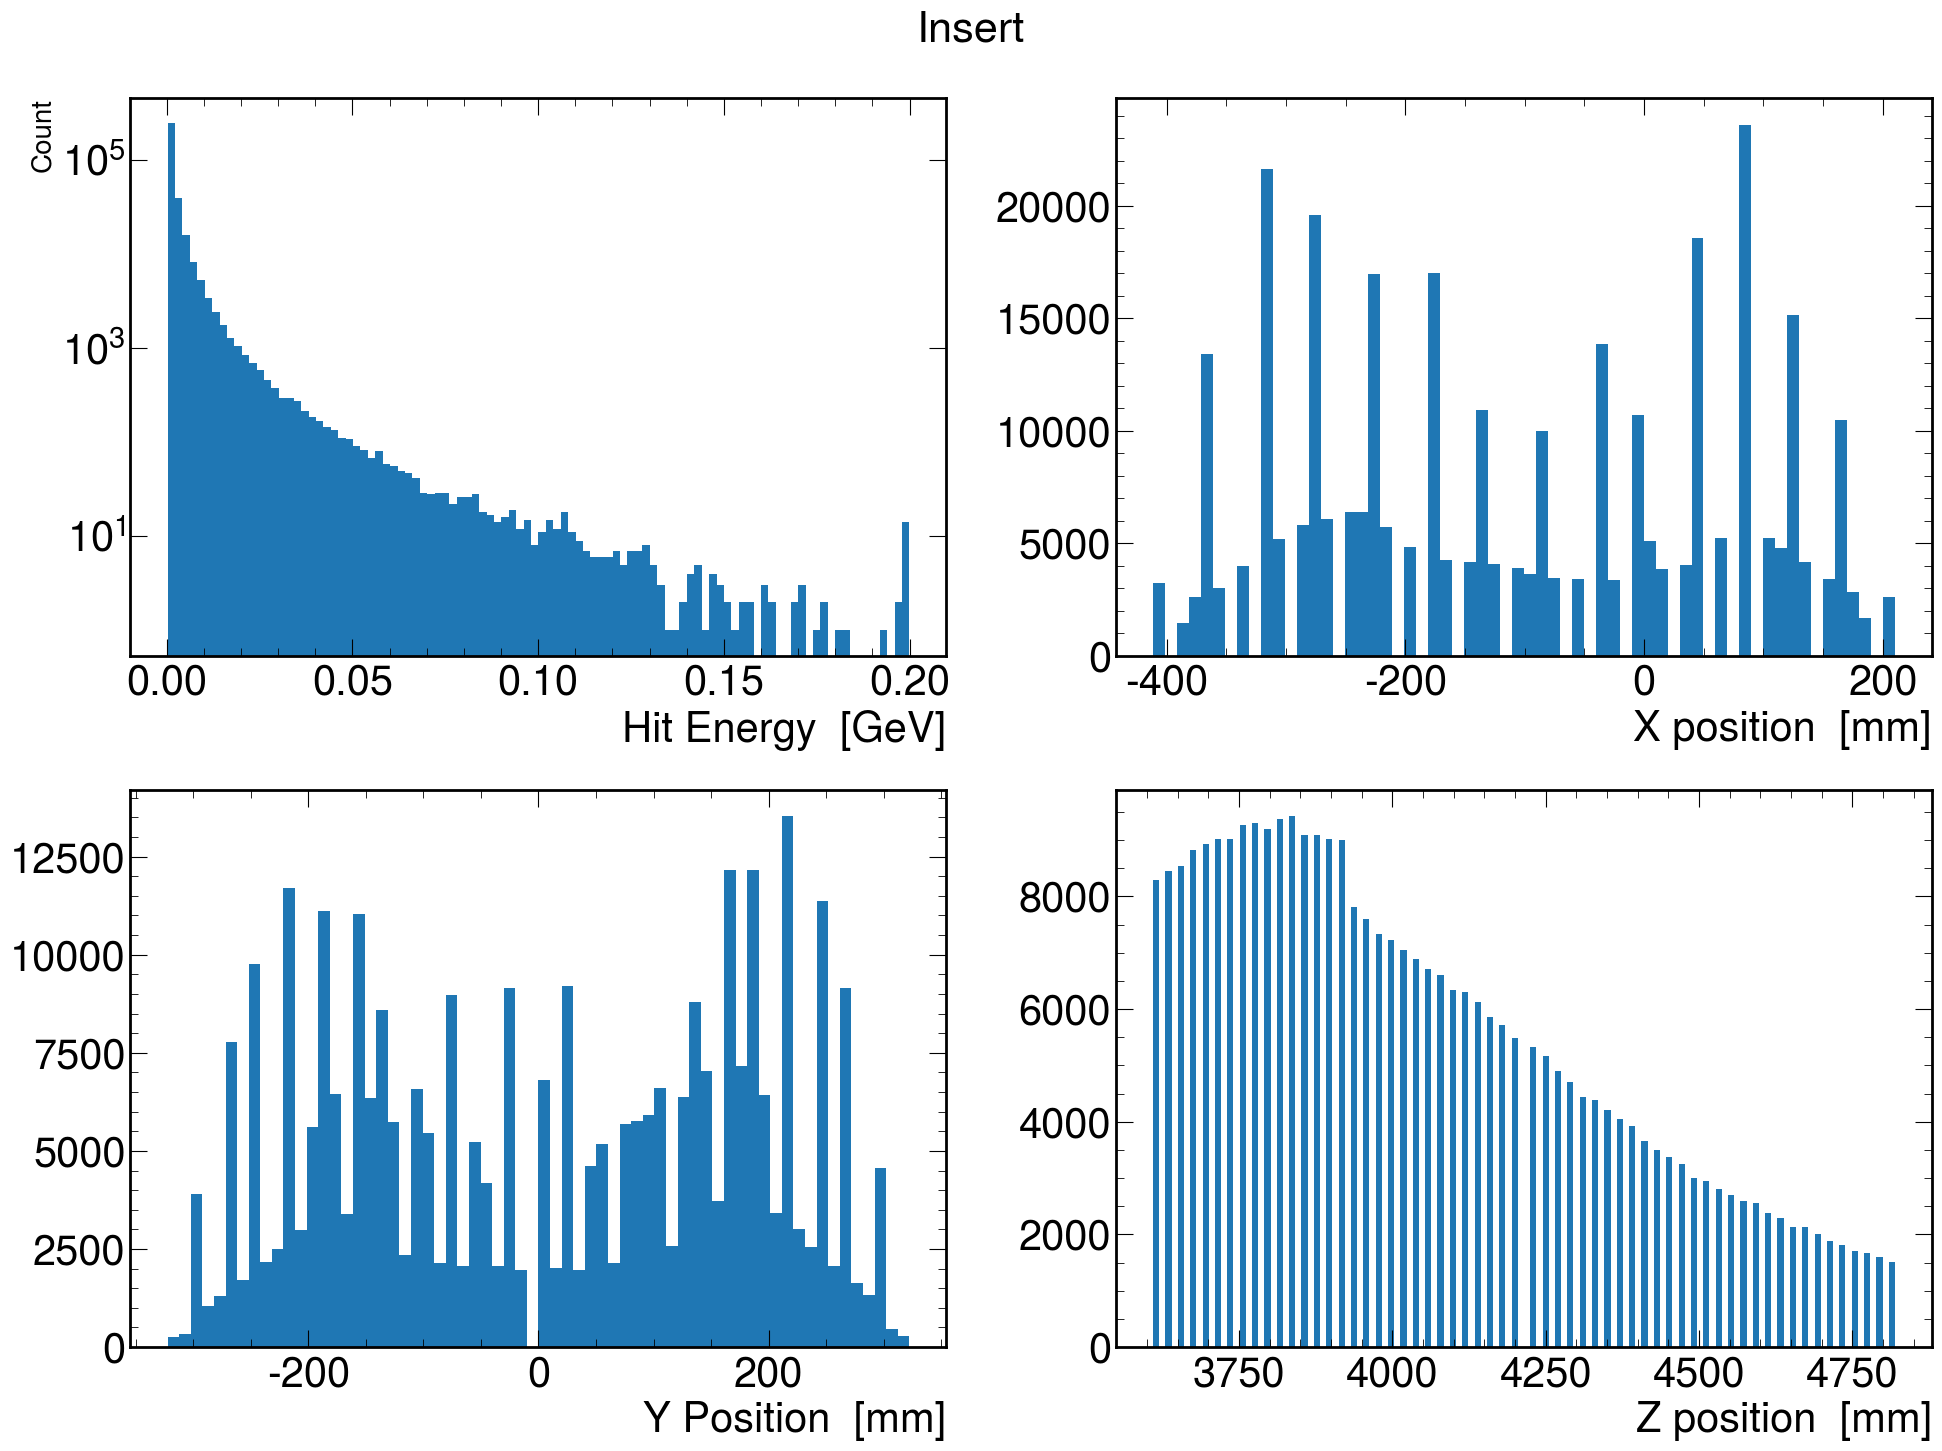

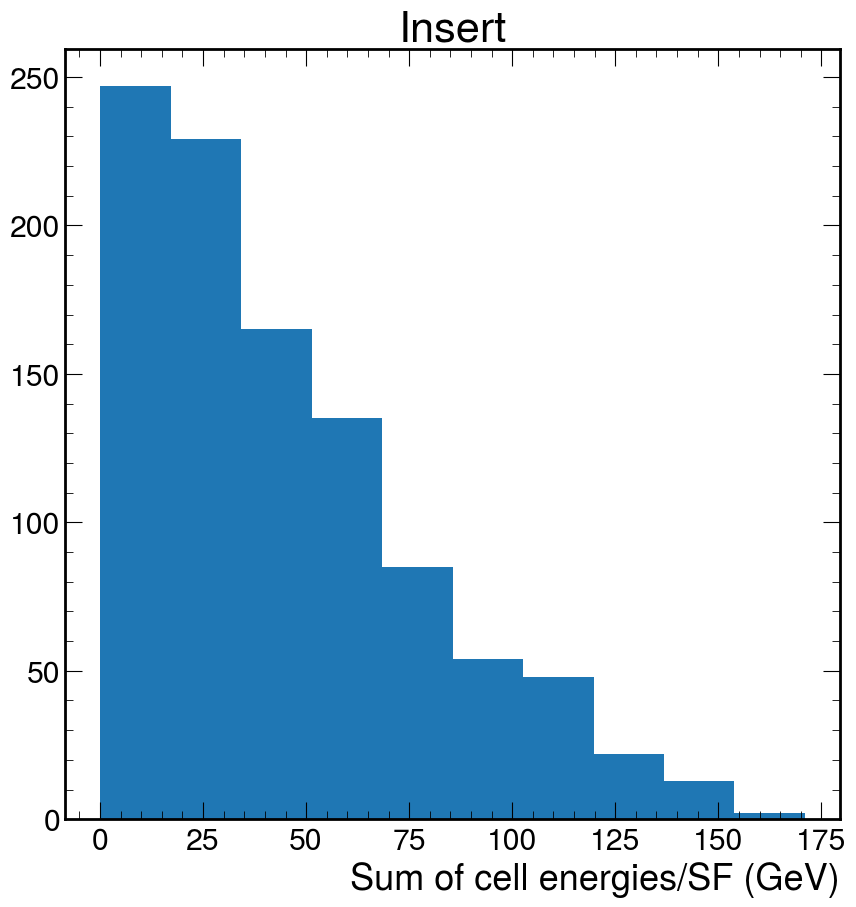

In [8]:
nrows=2
ncols=2
insert_cell_energies = reco["HcalEndcapPInsertRecHits.energy"]
insert_cell_times = reco["HcalEndcapPInsertRecHits.time"]
insert_x_pos = reco["HcalEndcapPInsertRecHits.position.x"]
insert_y_pos = reco["HcalEndcapPInsertRecHits.position.y"]
insert_z_pos = reco["HcalEndcapPInsertRecHits.position.z"]

fig2, ax2 = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 15))
variables=[insert_cell_energies, insert_x_pos, insert_y_pos, insert_z_pos]
titles=['Hit Energy','X position', 'Y Position', 'Z position']
for index, (variable, title) in enumerate(zip(variables, titles)):
    irow=int(index/nrows)
    icol=index%ncols
    min_range=np.min(ak.flatten(variable))
    max_range=np.max(ak.flatten(variable))
    
    if index==0:
        ax2[irow, icol].set_ylabel("Count", fontsize=20)
        ax2[irow, icol].set_xlabel(f"{titles[index]}  [GeV]", fontsize=30)
        ax2[irow, icol].set_yscale('log')
        nbins=100
    else:    
        nbins=int((max_range-min_range)/10.0) 
        ax2[irow, icol].set_xlabel(f"{titles[index]}  [mm]", fontsize=30)
        
    ax2[irow, icol].hist(ak.flatten(variable), bins=nbins, histtype='stepfilled', linewidth=3)
    
    ax2[irow, icol].yaxis.set_tick_params(labelsize=30)
    ax2[irow, icol].xaxis.set_tick_params(labelsize=30)
plt.subplots_adjust(wspace=0.3, hspace=0.2)    
plt.suptitle("Insert")
plt.tight_layout()
# pdf_pages.savefig(fig2,   bbox_inches='tight')
fig = plt.figure()
plt.hist(ak.sum(insert_cell_energies, axis=1)/.02)
plt.xlabel("Sum of cell energies/SF (GeV)")
plt.title("Insert")

[[3.51e+03, 3.51e+03, 3.51e+03, ..., 3.51e+03, 3.51e+03, 3.51e+03], ..., [...]]


Text(0.5, 1.0, 'ECal Insert')

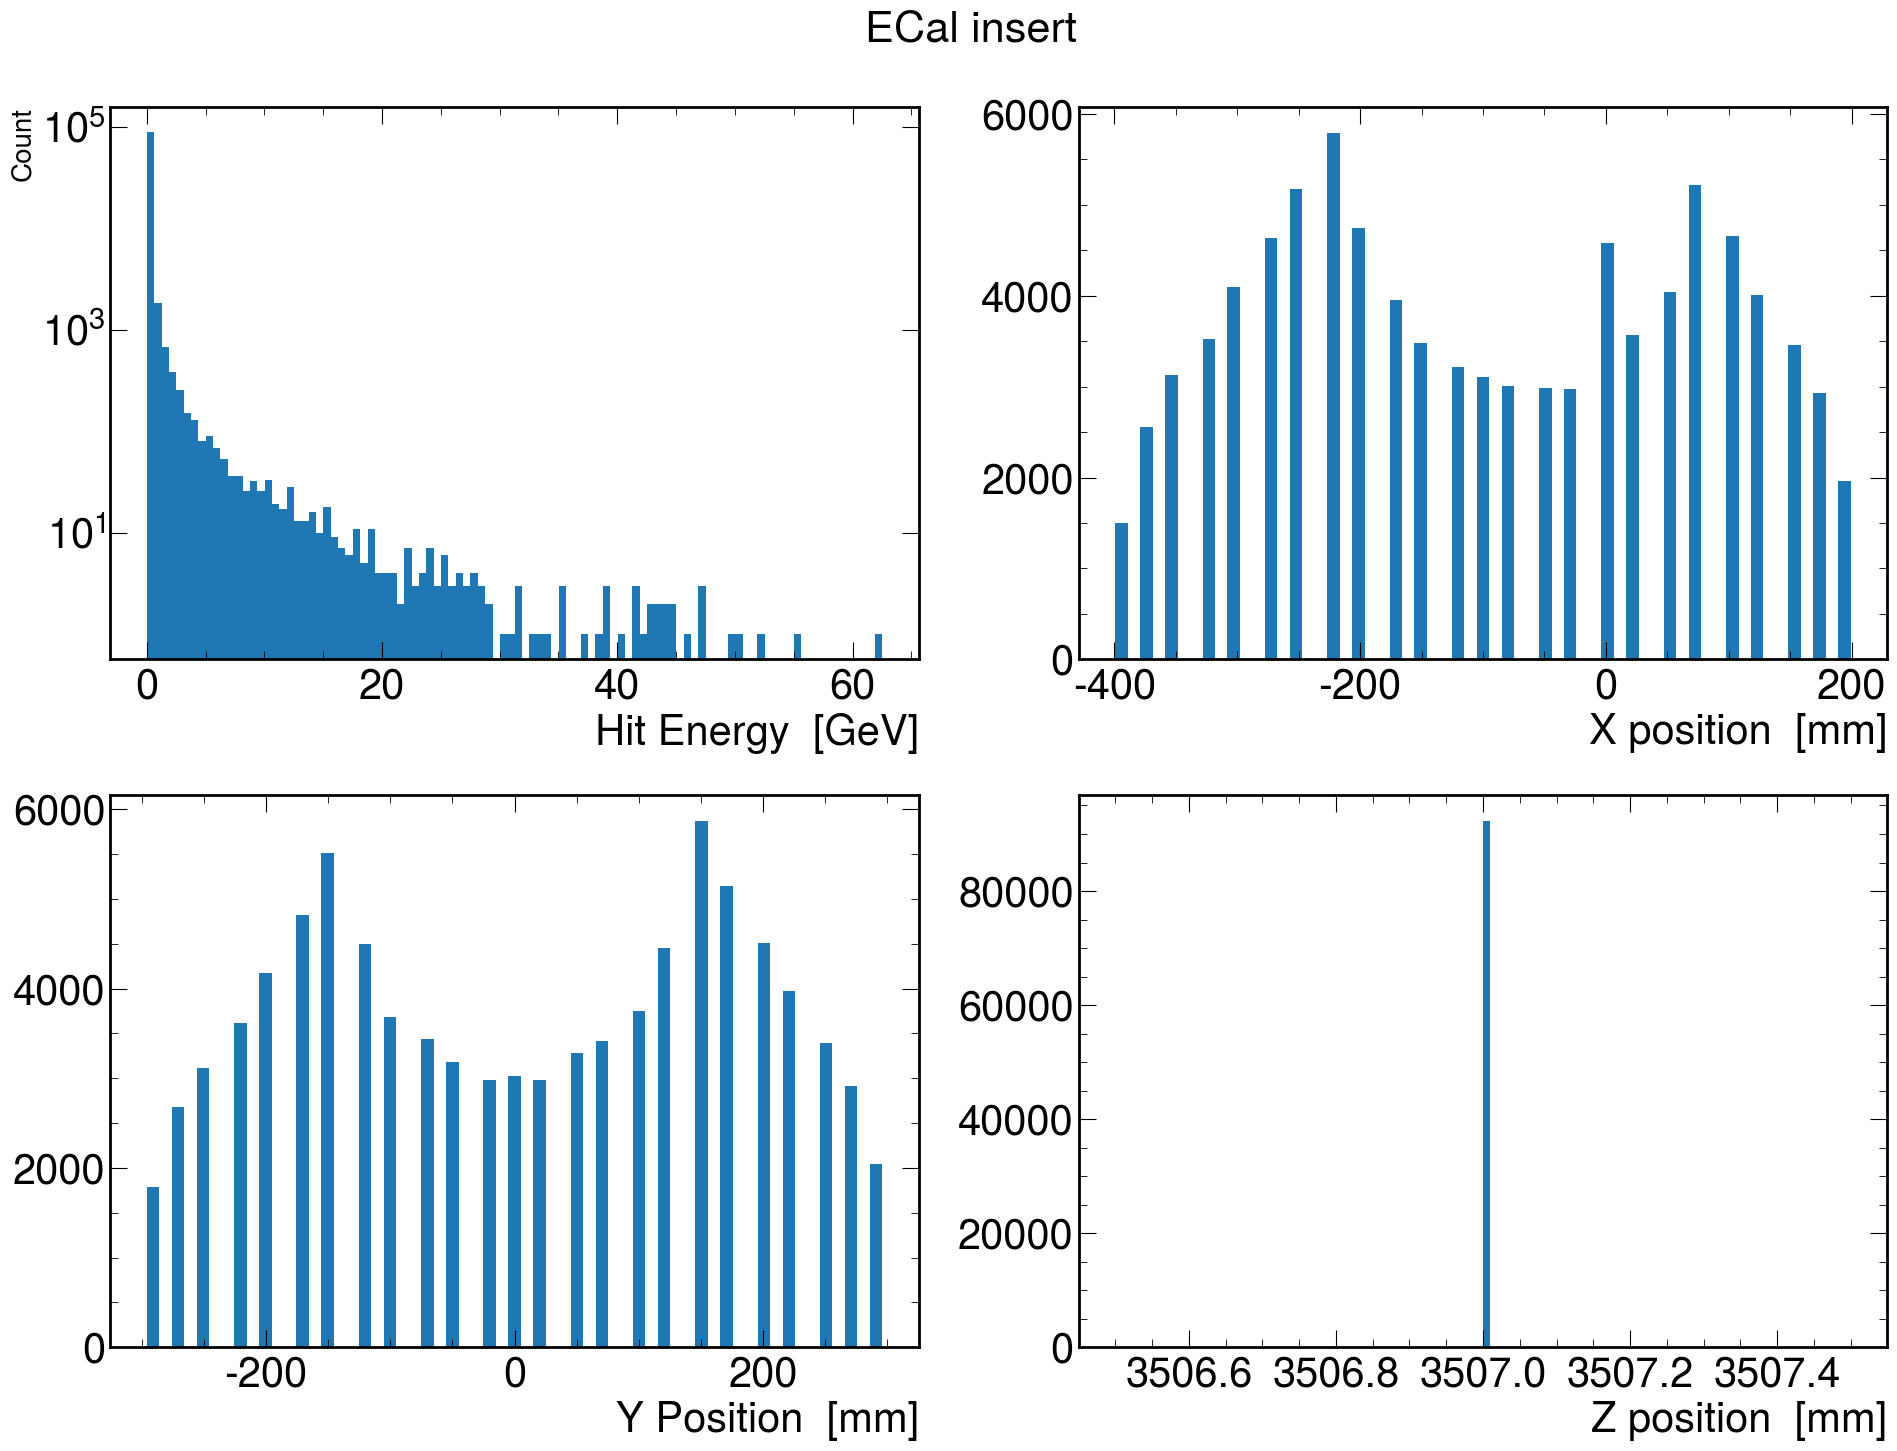

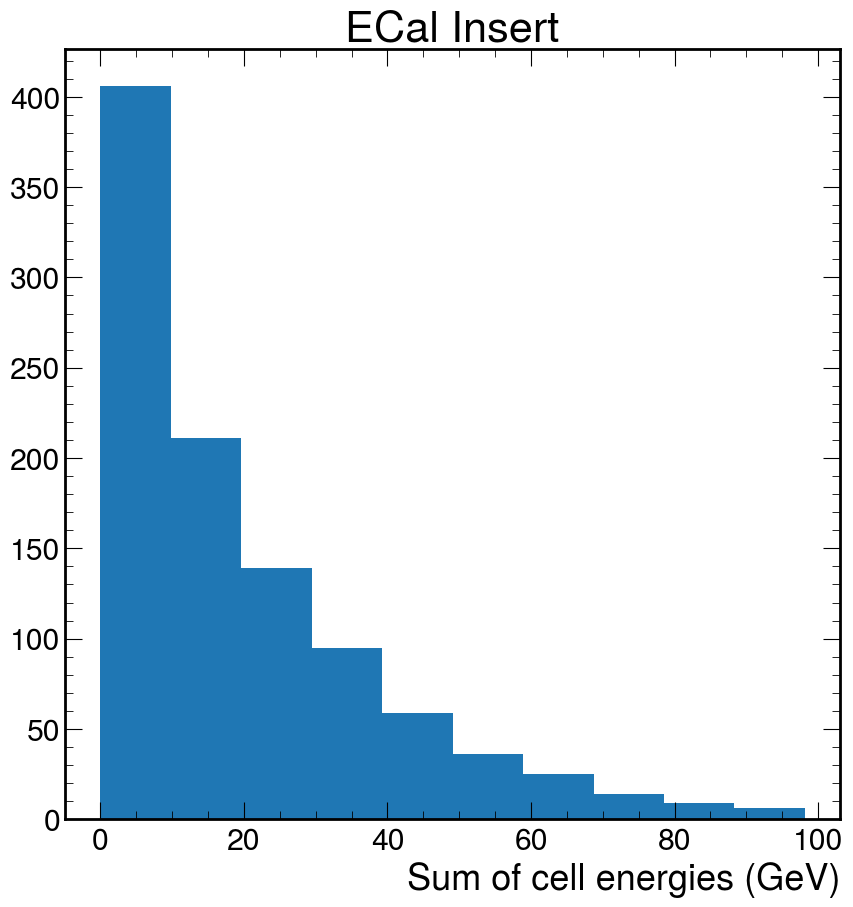

In [9]:
nrows=2
ncols=2
ecal_insert_cell_energies = reco["EcalEndcapPInsertRecHits.energy"]
ecal_insert_cell_times = reco["EcalEndcapPInsertRecHits.time"]
ecal_insert_x_pos = reco["EcalEndcapPInsertRecHits.position.x"]
ecal_insert_y_pos = reco["EcalEndcapPInsertRecHits.position.y"]
ecal_insert_z_pos = reco["EcalEndcapPInsertRecHits.position.z"]
print(ecal_insert_z_pos)
fig2, ax2 = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 15))
variables=[ecal_insert_cell_energies, ecal_insert_x_pos, ecal_insert_y_pos, ecal_insert_z_pos]
titles=['Hit Energy','X position', 'Y Position', 'Z position']
for index, (variable, title) in enumerate(zip(variables, titles)):
    irow=int(index/nrows)
    icol=index%ncols
    min_range=np.min(ak.flatten(variable))
    max_range=np.max(ak.flatten(variable))
        
    if index==0:
        ax2[irow, icol].set_ylabel("Count", fontsize=20)
        ax2[irow, icol].set_xlabel(f"{titles[index]}  [GeV]", fontsize=30)
        ax2[irow, icol].set_yscale('log')
        nbins=100
    else:    
        nbins=int((max_range-min_range)/10.0) 
        ax2[irow, icol].set_xlabel(f"{titles[index]}  [mm]", fontsize=30)
    if nbins == 0:
        nbins = 100
    ax2[irow, icol].hist(ak.flatten(variable), bins=nbins, histtype='stepfilled', linewidth=3)
    
    ax2[irow, icol].yaxis.set_tick_params(labelsize=30)
    ax2[irow, icol].xaxis.set_tick_params(labelsize=30)
plt.subplots_adjust(wspace=0.3, hspace=0.2)    
plt.suptitle("ECal insert")
plt.tight_layout()
# pdf_pages.savefig(fig2,   bbox_inches='tight')
fig = plt.figure()
plt.hist(ak.sum(ecal_insert_cell_energies, axis=1))
plt.xlabel("Sum of cell energies (GeV)")
plt.title("ECal Insert")

Text(0.5, 1.0, 'ECal')

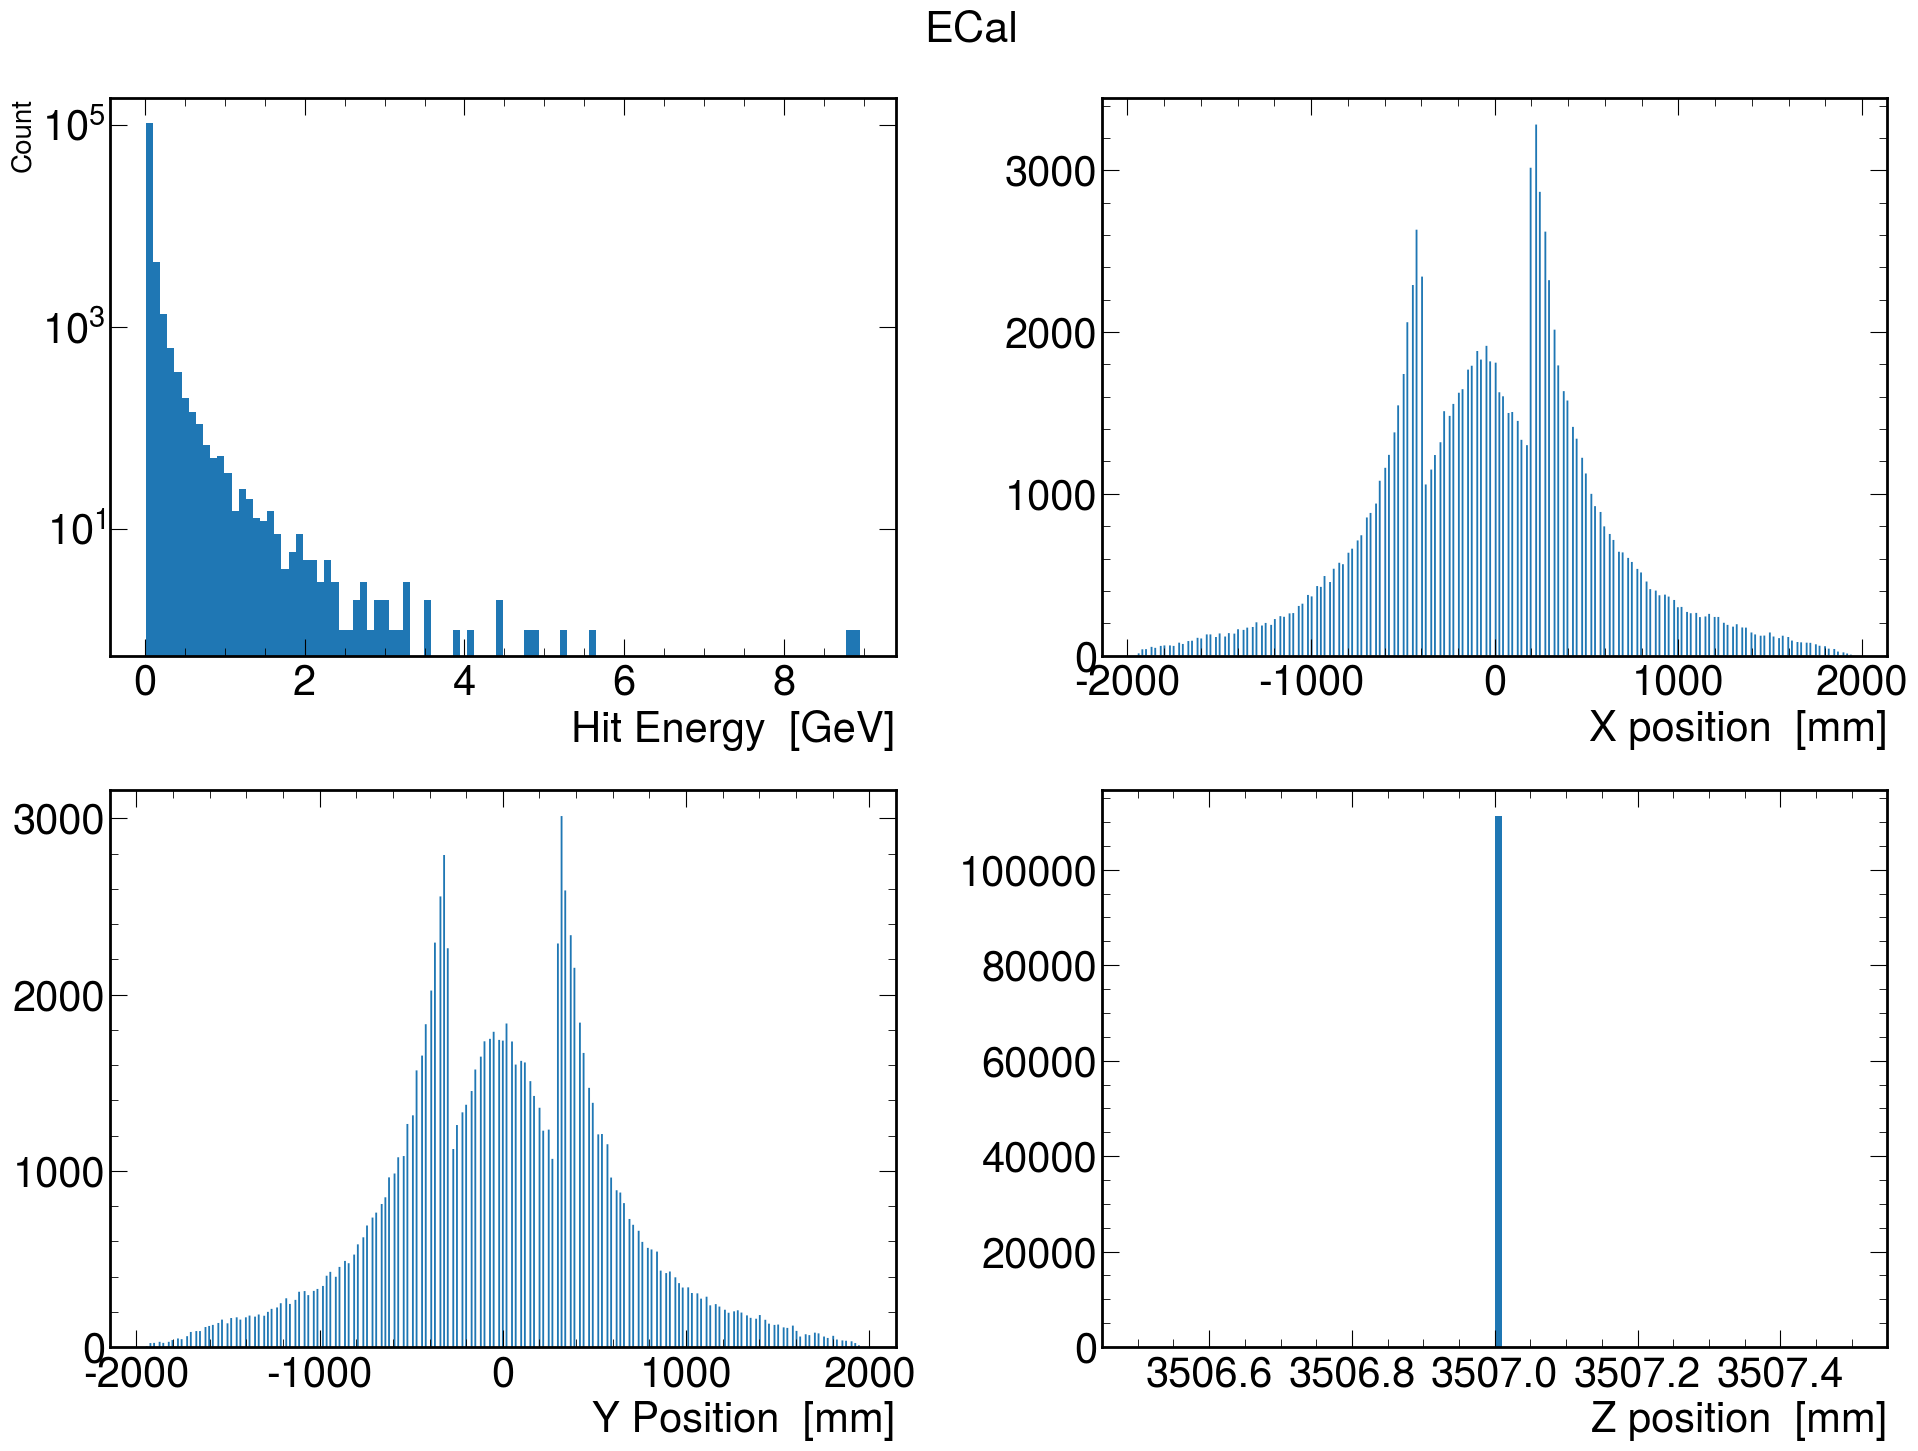

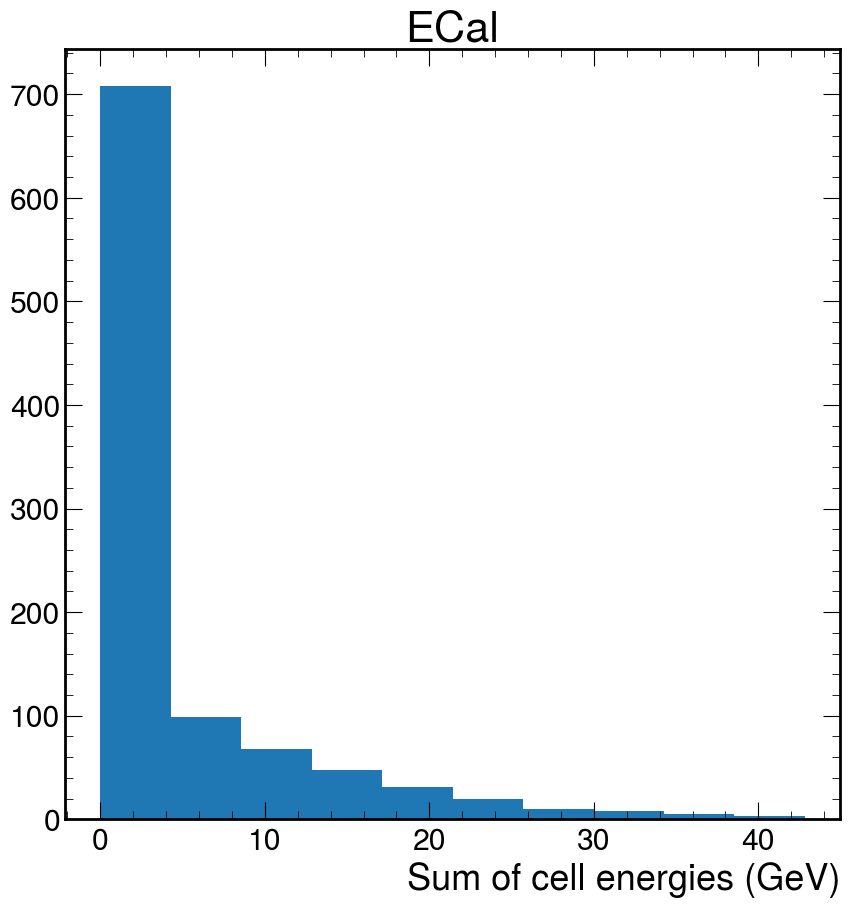

In [10]:
nrows=2
ncols=2
ecal_cell_energies = reco["EcalEndcapPRecHits.energy"]
ecal_cell_times = reco["EcalEndcapPRecHits.time"]
ecal_x_pos = reco["EcalEndcapPRecHits.position.x"]
ecal_y_pos = reco["EcalEndcapPRecHits.position.y"]
ecal_z_pos = reco["EcalEndcapPRecHits.position.z"]

fig2, ax2 = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 15))
variables=[ecal_cell_energies, ecal_x_pos, ecal_y_pos, ecal_z_pos]
titles=['Hit Energy','X position', 'Y Position', 'Z position']
for index, (variable, title) in enumerate(zip(variables, titles)):
    irow=int(index/nrows)
    icol=index%ncols
    min_range=np.min(ak.flatten(variable))
    max_range=np.max(ak.flatten(variable))
        
    if index==0:
        ax2[irow, icol].set_ylabel("Count", fontsize=20)
        ax2[irow, icol].set_xlabel(f"{titles[index]}  [GeV]", fontsize=30)
        ax2[irow, icol].set_yscale('log')
        nbins=100
    else:    
        nbins=int((max_range-min_range)/10.0) 
        ax2[irow, icol].set_xlabel(f"{titles[index]}  [mm]", fontsize=30)
    if nbins == 0:
        nbins = 100
    ax2[irow, icol].hist(ak.flatten(variable), bins=nbins, histtype='stepfilled', linewidth=3)
    
    ax2[irow, icol].yaxis.set_tick_params(labelsize=30)
    ax2[irow, icol].xaxis.set_tick_params(labelsize=30)
plt.subplots_adjust(wspace=0.3, hspace=0.2)    
plt.suptitle("ECal")
plt.tight_layout()
# pdf_pages.savefig(fig2,   bbox_inches='tight')
fig = plt.figure()
plt.hist(ak.sum(ecal_cell_energies, axis=1))
plt.xlabel("Sum of cell energies (GeV)")
plt.title("ECal")

100
519
519
120


Text(0.5, 1.0, 'HCal')

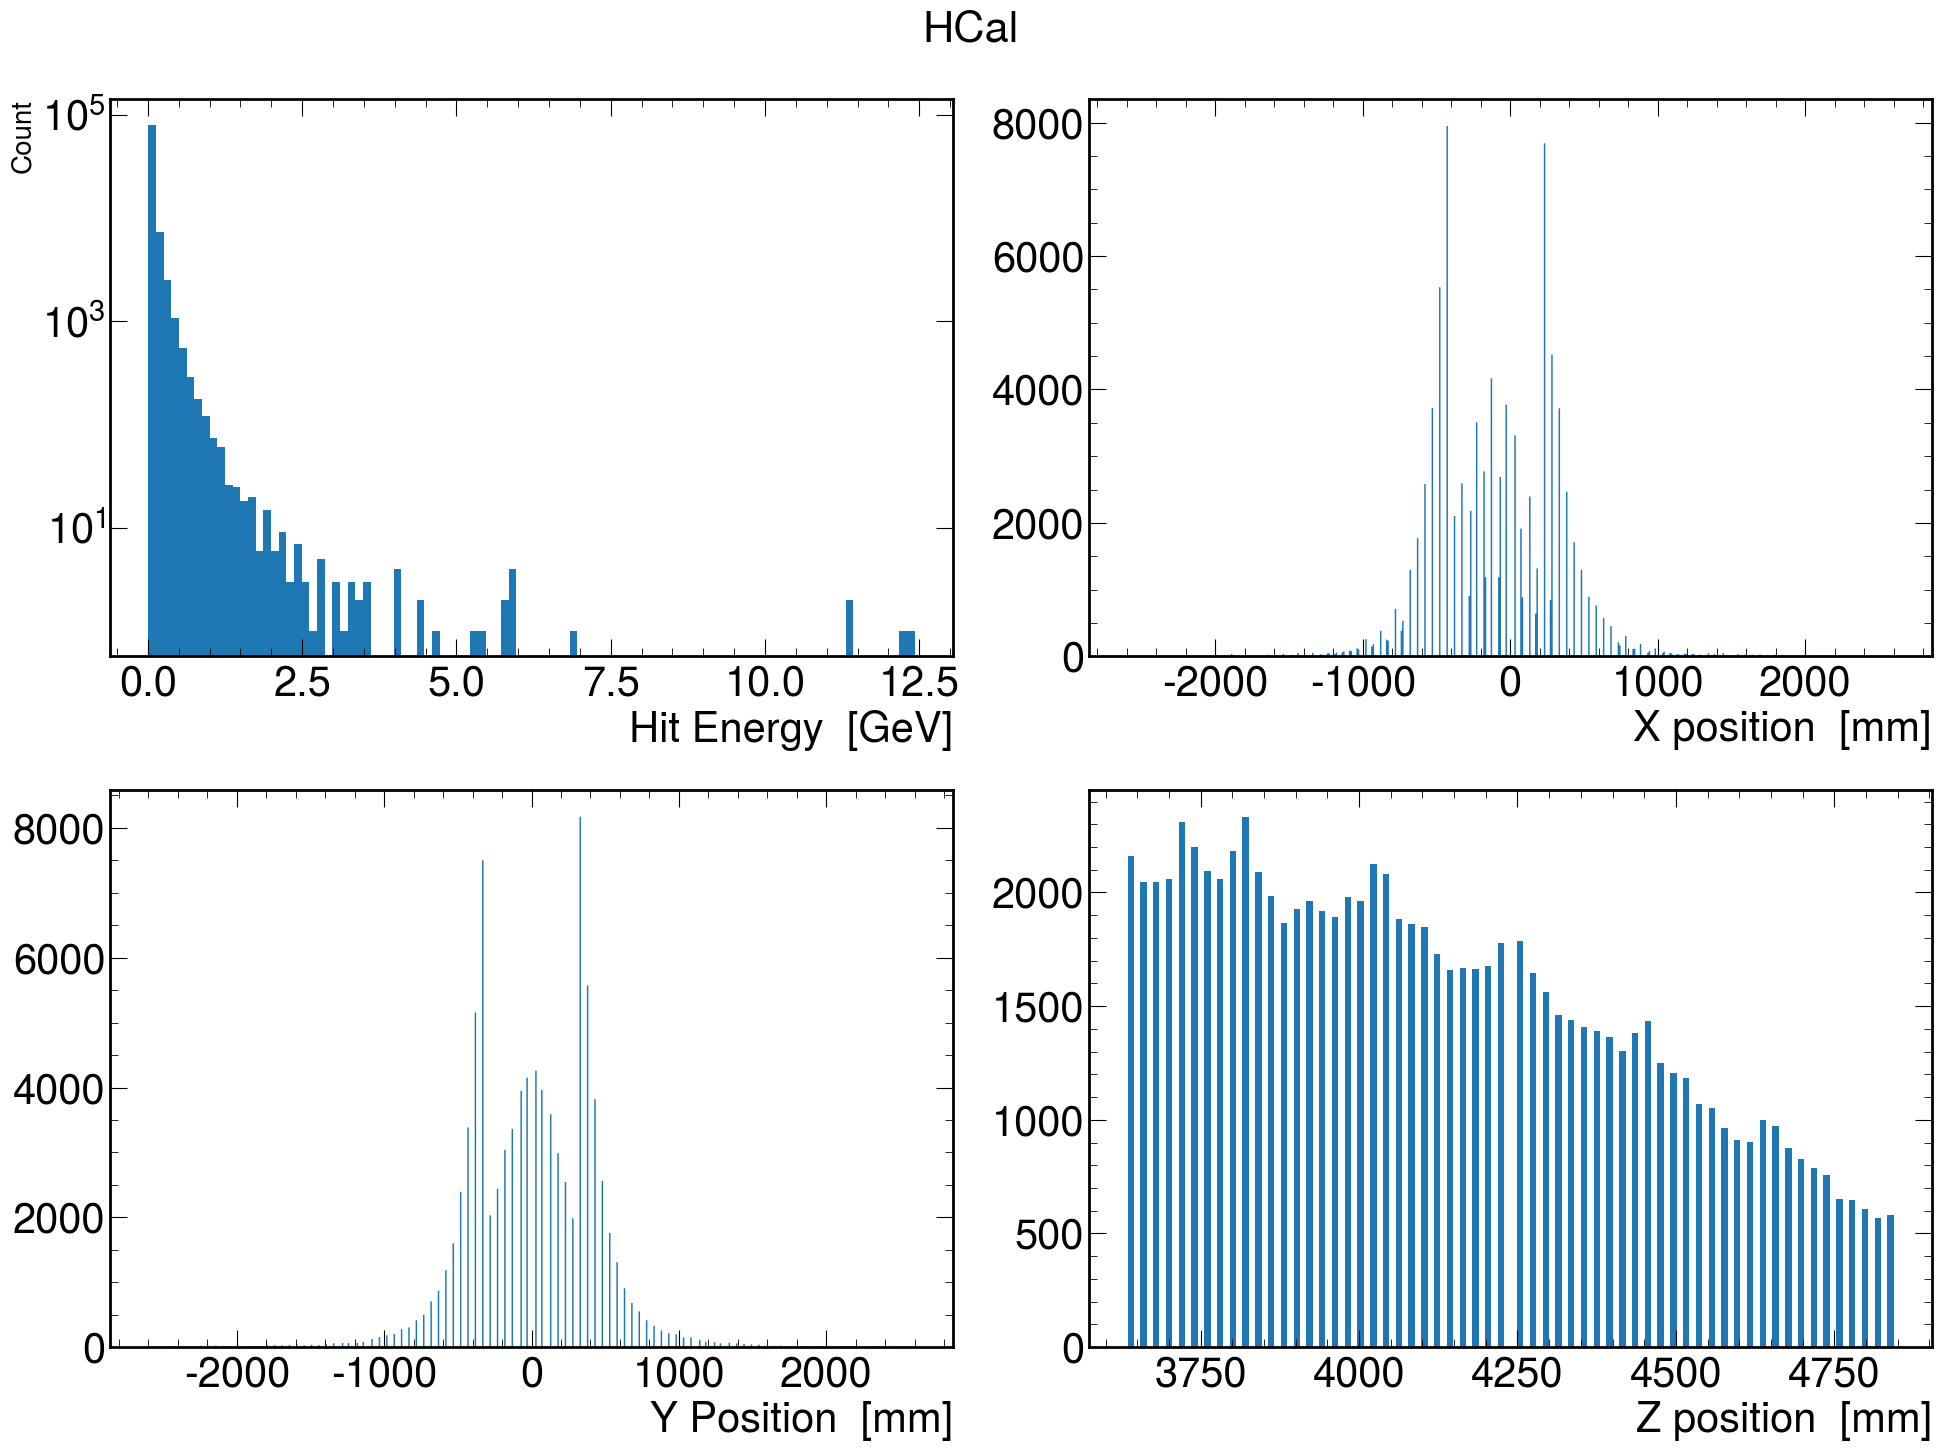

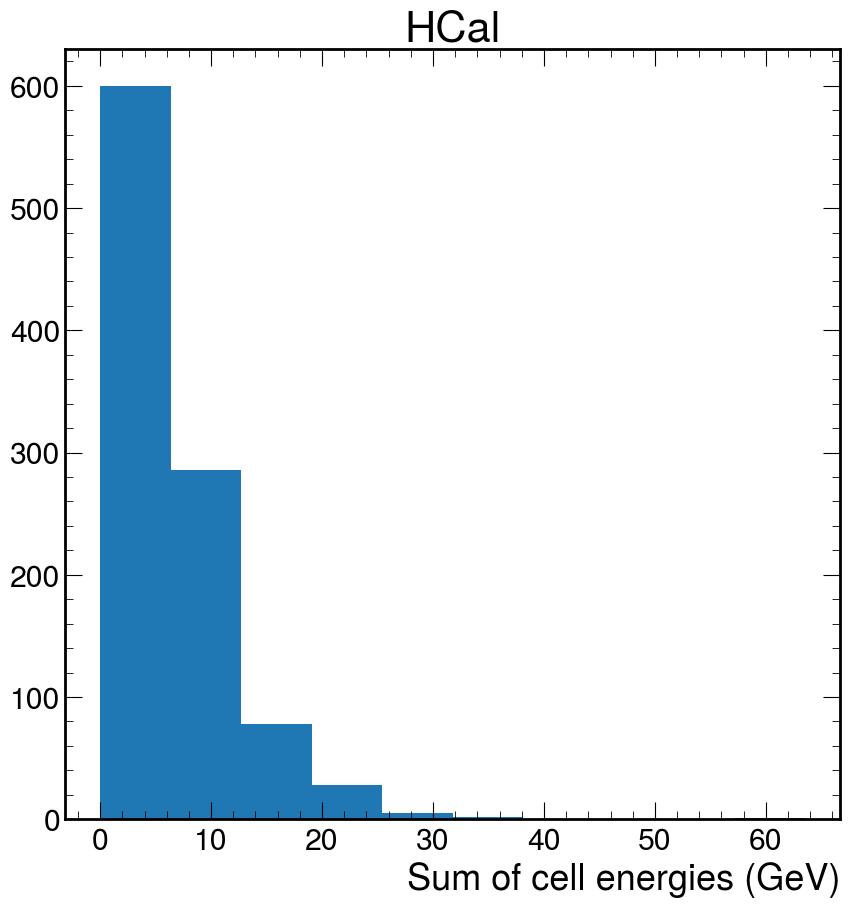

In [11]:
nrows=2
ncols=2
hcal_cell_energies = reco["LFHCALRecHits.energy"]
hcal_cell_times = reco["LFHCALRecHits.time"]
hcal_x_pos = reco["LFHCALRecHits.position.x"]
hcal_y_pos = reco["LFHCALRecHits.position.y"]
hcal_z_pos = reco["LFHCALRecHits.position.z"]

fig2, ax2 = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 15))
variables=[hcal_cell_energies, hcal_x_pos, hcal_y_pos, hcal_z_pos]
titles=['Hit Energy','X position', 'Y Position', 'Z position']
for index, (variable, title) in enumerate(zip(variables, titles)):
    irow=int(index/nrows)
    icol=index%ncols
    min_range=np.min(ak.flatten(variable))
    max_range=np.max(ak.flatten(variable))
        
    if index==0:
        ax2[irow, icol].set_ylabel("Count", fontsize=20)
        ax2[irow, icol].set_xlabel(f"{titles[index]}  [GeV]", fontsize=30)
        ax2[irow, icol].set_yscale('log')
        nbins=100
    else:    
        nbins=int((max_range-min_range)/10.0) 
        ax2[irow, icol].set_xlabel(f"{titles[index]}  [mm]", fontsize=30)
    print(nbins)
    if nbins == 0:
        nbins = 100
    ax2[irow, icol].hist(ak.flatten(variable), bins=nbins, histtype='stepfilled', linewidth=3)
    
    ax2[irow, icol].yaxis.set_tick_params(labelsize=30)
    ax2[irow, icol].xaxis.set_tick_params(labelsize=30)
plt.subplots_adjust(wspace=0.3, hspace=0.2)
plt.suptitle("HCal")
plt.tight_layout()
# pdf_pages.savefig(fig2,   bbox_inches='tight')
fig = plt.figure()
plt.hist(ak.sum(hcal_cell_energies, axis=1))
plt.xlabel("Sum of cell energies (GeV)")
plt.title("HCal")

Text(0, 1, 'Reconstructed energy (GeV)')

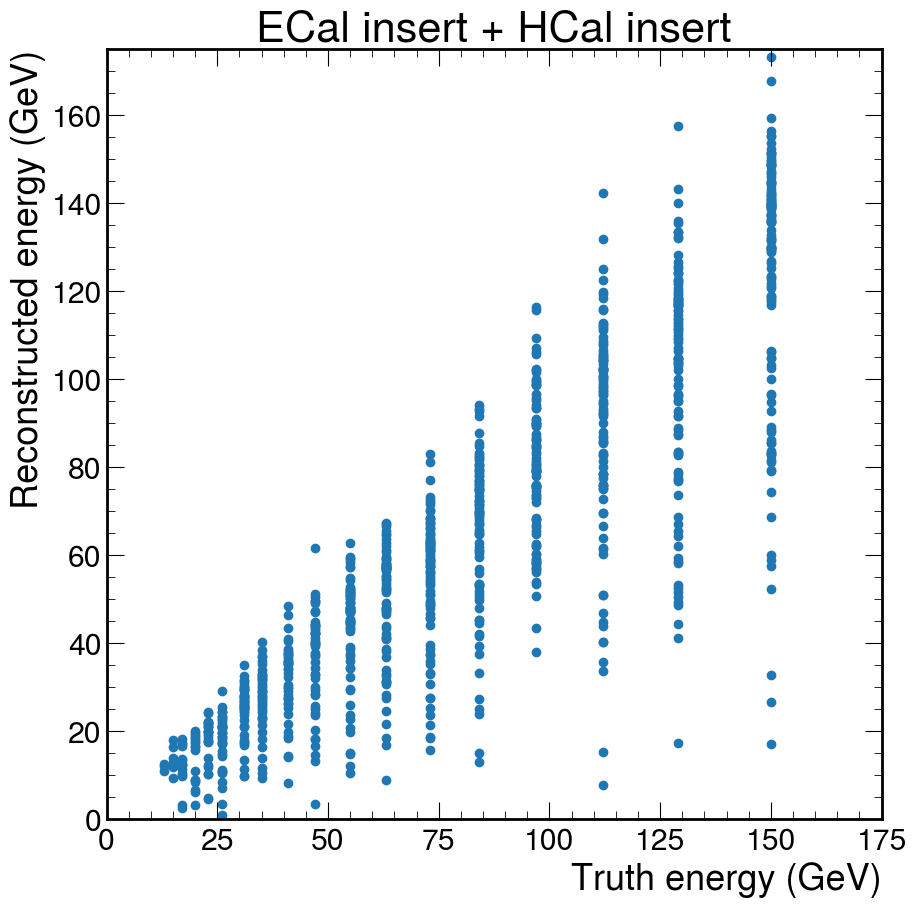

In [12]:
reco_energy = ak.sum(ecal_insert_cell_energies, axis=1)+ak.sum(insert_cell_energies, axis=1)/.02
plt.scatter(ak.flatten(energy), reco_energy)
plt.ylim(0,175)
plt.xlim(0,175)
plt.title("ECal insert + HCal insert")
plt.xlabel("Truth energy (GeV)")
plt.ylabel("Reconstructed energy (GeV)")

Text(0, 1, 'Reconstructed energy (GeV)')

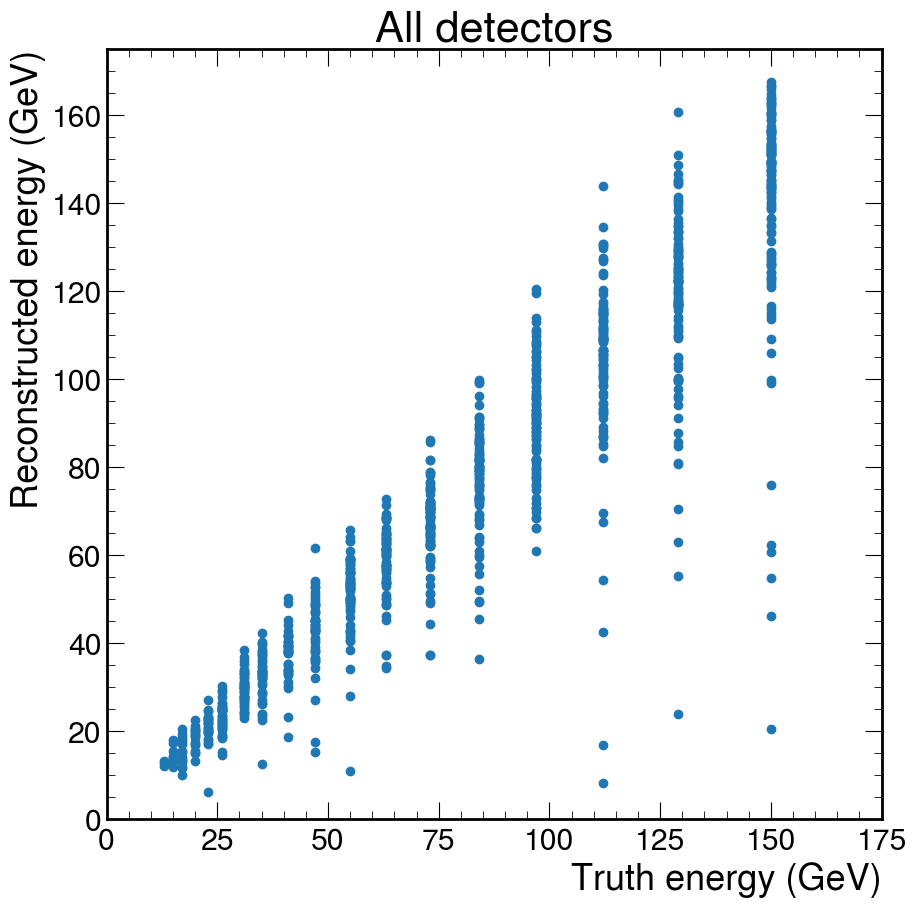

In [13]:
reco_energy = ak.sum(ecal_insert_cell_energies, axis=1)+ak.sum(ecal_cell_energies, axis=1)+ak.sum(insert_cell_energies, axis=1)/.02+ak.sum(hcal_cell_energies, axis=1)
plt.scatter(ak.flatten(energy), reco_energy)
plt.ylim(0,175)
plt.xlim(0,175)
plt.title("All detectors")
plt.xlabel("Truth energy (GeV)")
plt.ylabel("Reconstructed energy (GeV)")

[0.000299, 0.000275, 0.0023, 0.000592, ..., 0.00105, 0.000458, 0.000317]
17.01766811486227
[-23.2, -39, -26.7, -35.5, -35.5, -30.2, ..., -39, -19.7, -23.2, -30.2, -7.41]
3.09


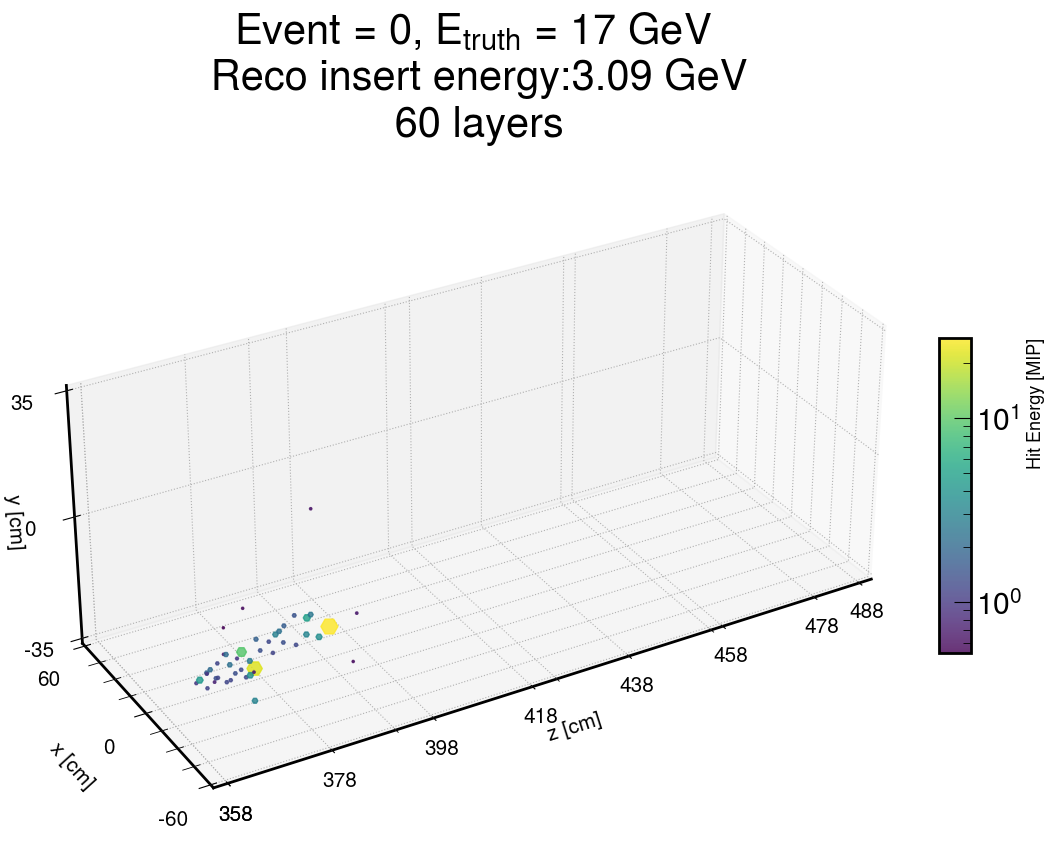

[0.000299, 0.000275, 0.0023, 0.000592, ..., 0.00105, 0.000458, 0.000317]
17.01766811486227
[-23.2, -39, -26.7, -35.5, -35.5, -30.2, ..., -39, -19.7, -23.2, -30.2, -7.41]
3.09


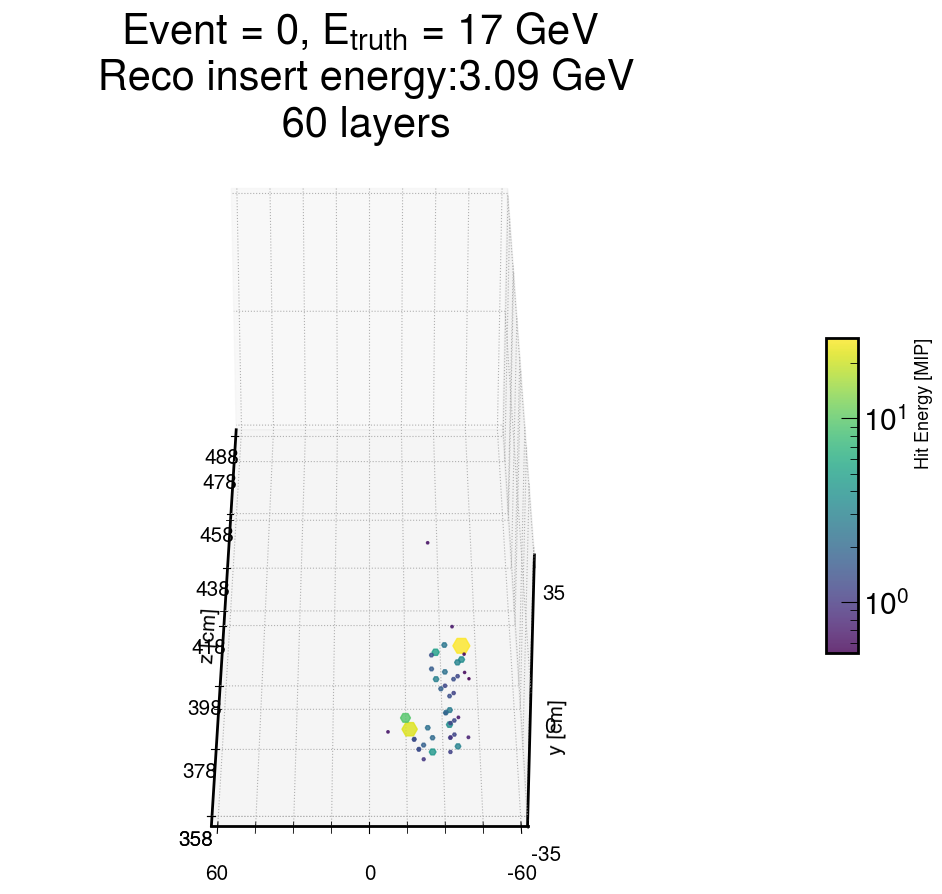

[0.000299, 0.000275, 0.0023, 0.000592, ..., 0.00105, 0.000458, 0.000317]
17.01766811486227
[-23.2, -39, -26.7, -35.5, -35.5, -30.2, ..., -39, -19.7, -23.2, -30.2, -7.41]
3.09


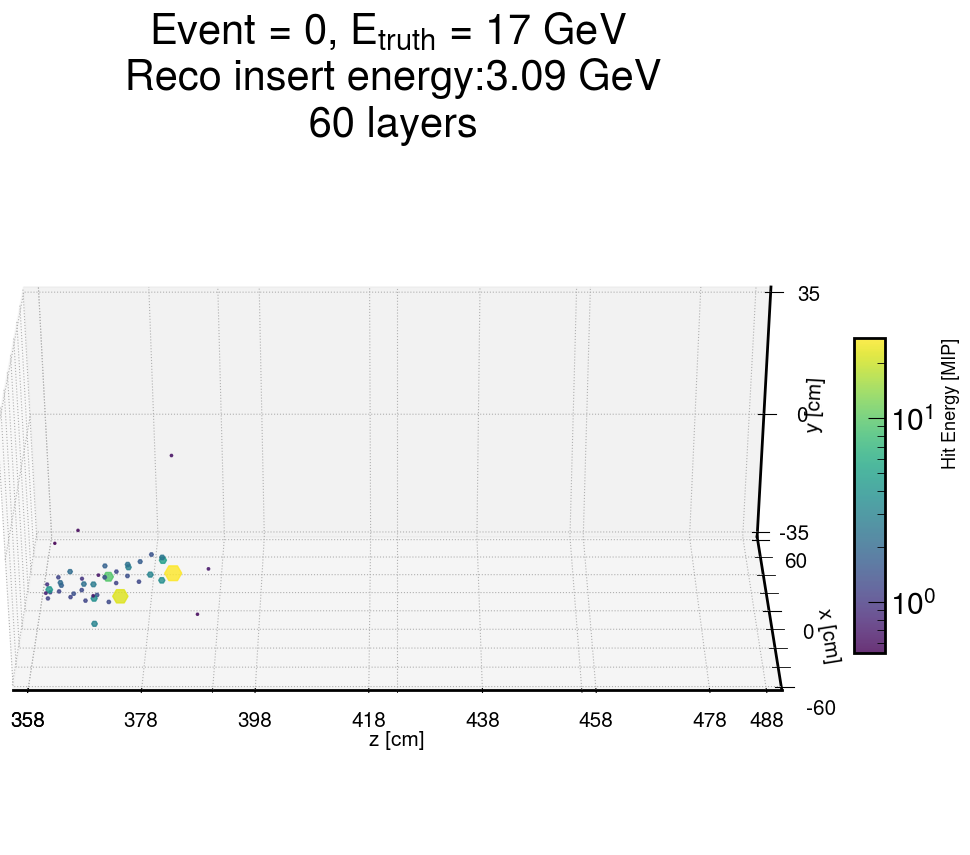

[0.000354, 0.000403, 0.00033, 0.000665, ..., 0.000494, 0.00175, 0.00221]
84.00357747184104
[-19.7, -0.29, -0.395, 3.21, -3.94, -21.5, ..., 12.5, -17.9, -17.9, 8.23, 3.97]
36.92


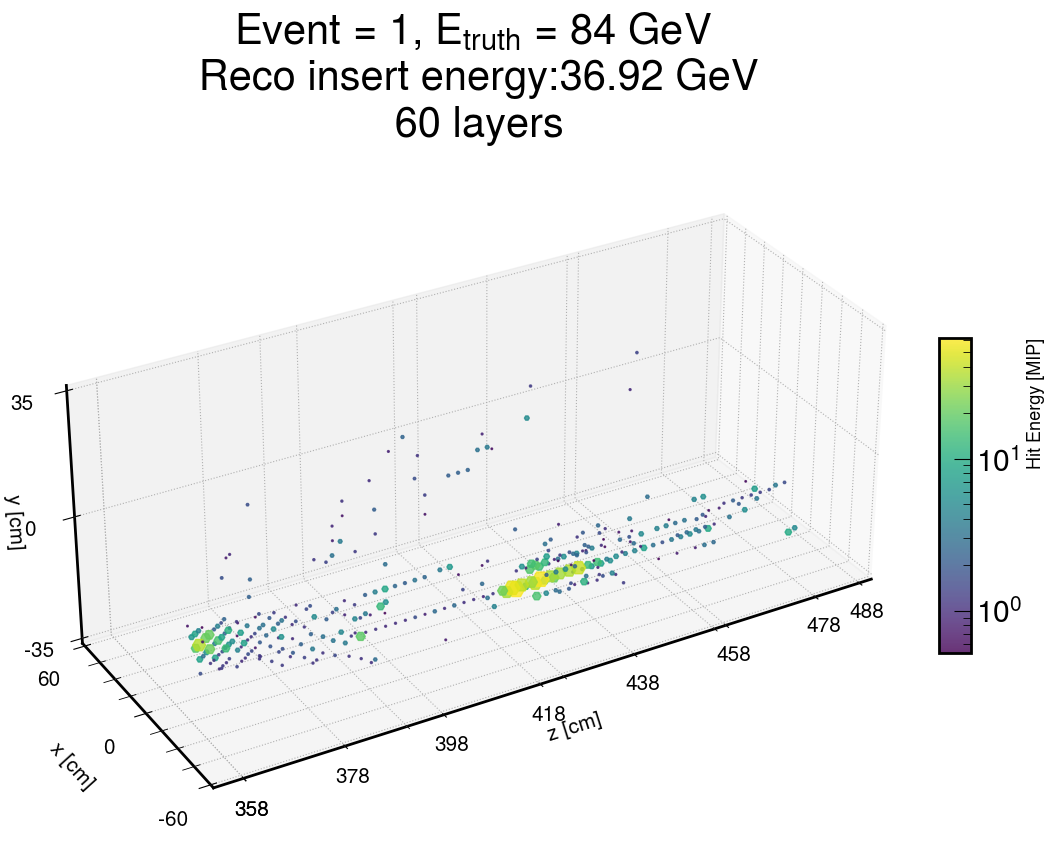

[0.000354, 0.000403, 0.00033, 0.000665, ..., 0.000494, 0.00175, 0.00221]
84.00357747184104
[-19.7, -0.29, -0.395, 3.21, -3.94, -21.5, ..., 12.5, -17.9, -17.9, 8.23, 3.97]
36.92


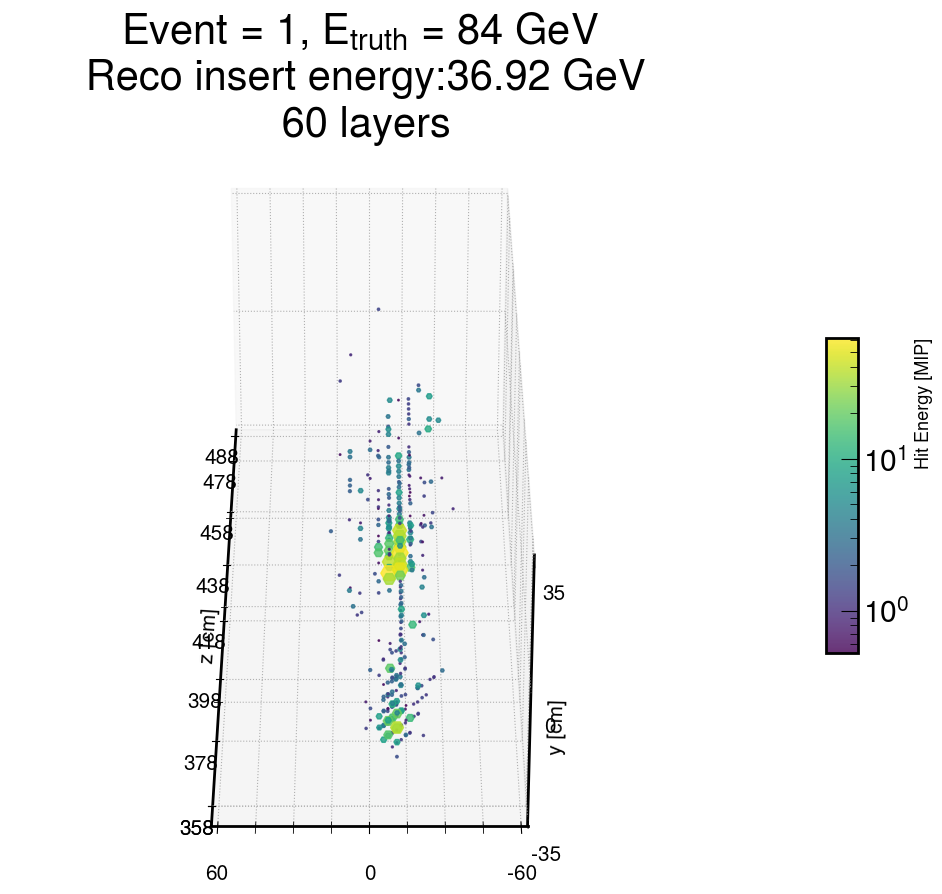

[0.000354, 0.000403, 0.00033, 0.000665, ..., 0.000494, 0.00175, 0.00221]
84.00357747184104
[-19.7, -0.29, -0.395, 3.21, -3.94, -21.5, ..., 12.5, -17.9, -17.9, 8.23, 3.97]
36.92


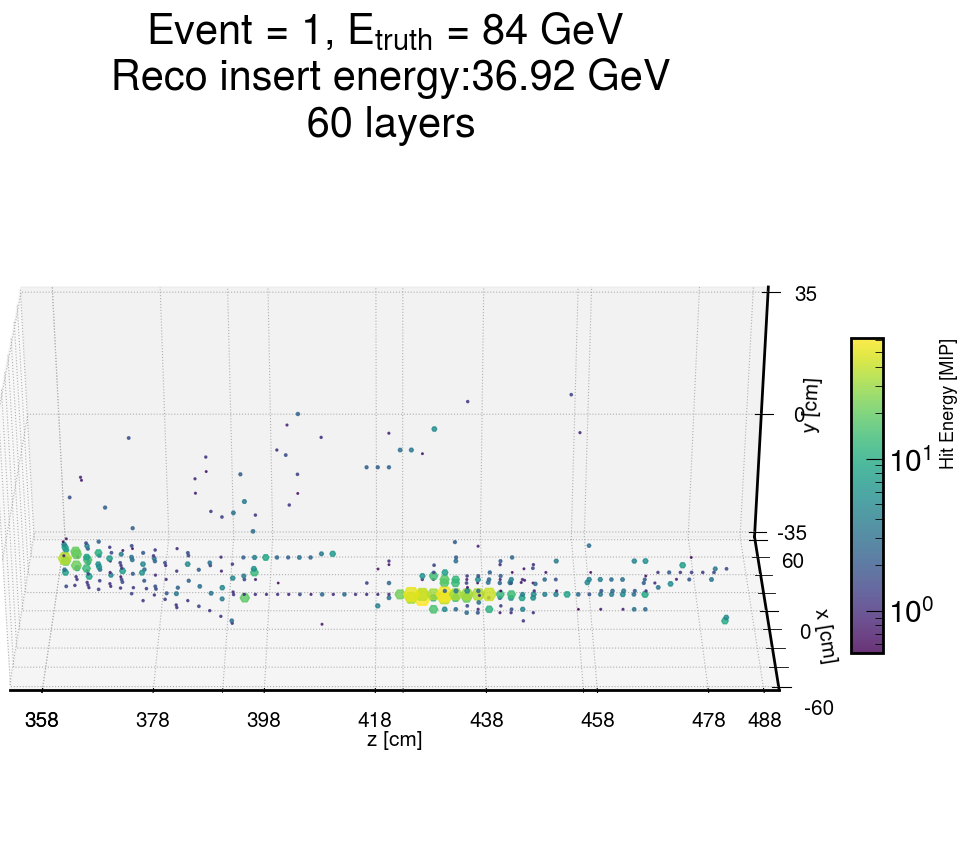

[0.000537, 0.000507, 0.000452, 0.00256, ..., 0.00181, 0.00851, 0.000452]
150.00200341351308
[-25, -33.7, -31.8, -27.2, -30.2, -36.5, ..., -36.5, -13.2, -36.5, -36.5, -3.94]
142.14


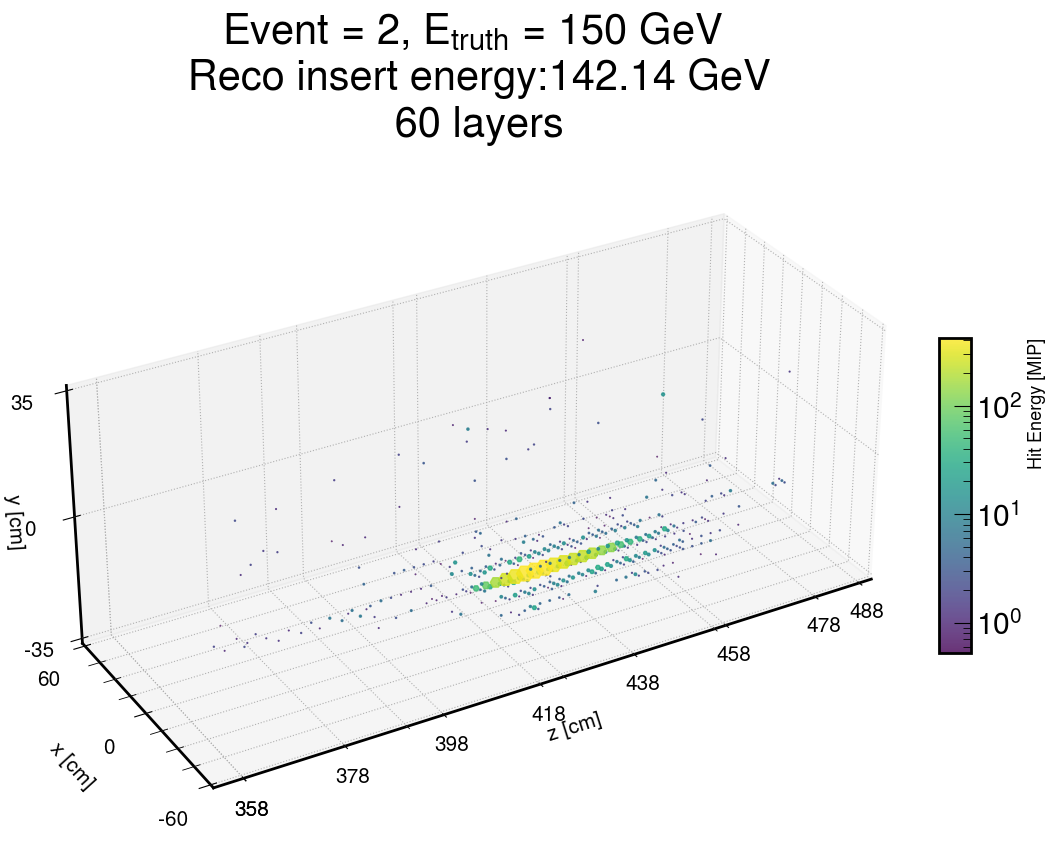

[0.000537, 0.000507, 0.000452, 0.00256, ..., 0.00181, 0.00851, 0.000452]
150.00200341351308
[-25, -33.7, -31.8, -27.2, -30.2, -36.5, ..., -36.5, -13.2, -36.5, -36.5, -3.94]
142.14


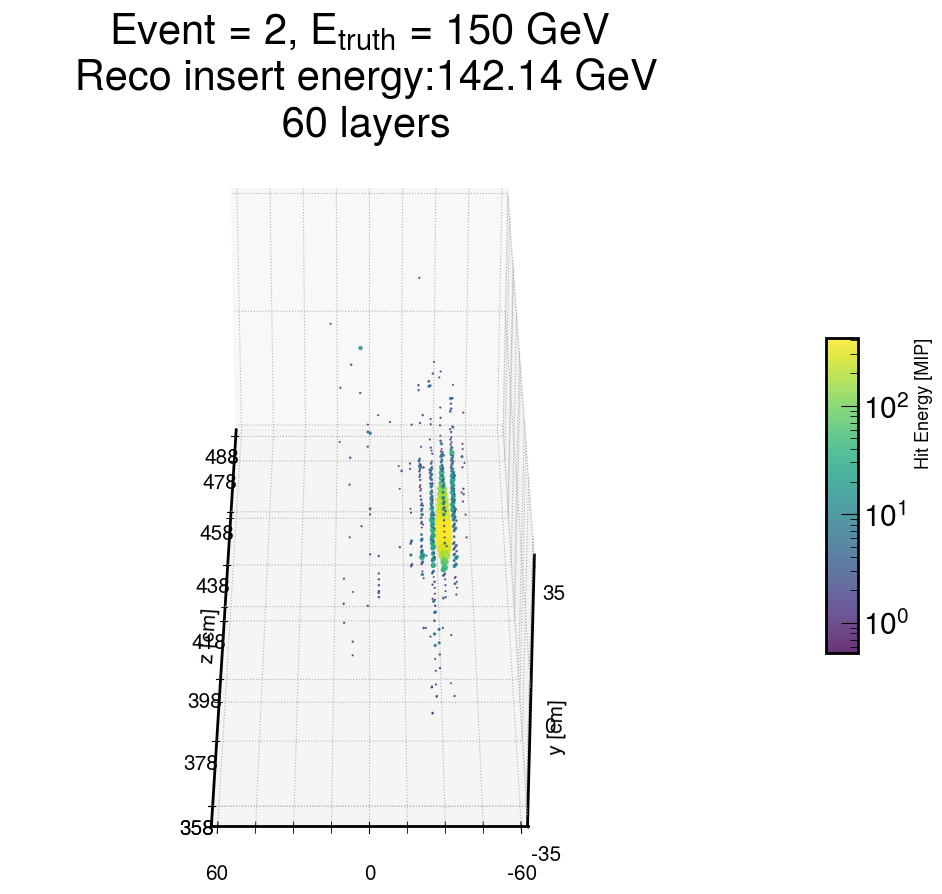

[0.000537, 0.000507, 0.000452, 0.00256, ..., 0.00181, 0.00851, 0.000452]
150.00200341351308
[-25, -33.7, -31.8, -27.2, -30.2, -36.5, ..., -36.5, -13.2, -36.5, -36.5, -3.94]
142.14


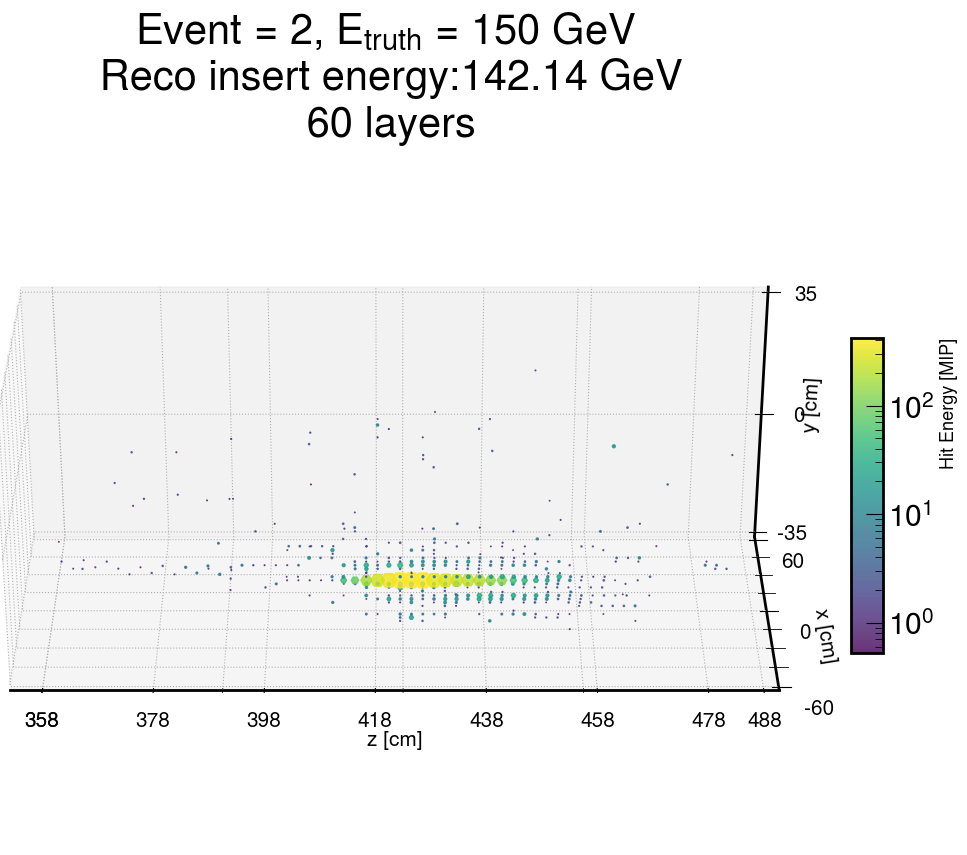

[0.000568, 0.00784, 0.00289, 0.000995, ..., 0.00036, 0.00201, 0.00047, 0.00211]
55.00546362014959
[-10.9, -17.9, -16.2, 10.2, 8.48, -10.9, ..., 3.21, -21.5, -19.7, 3.21, -21.5]
46.22


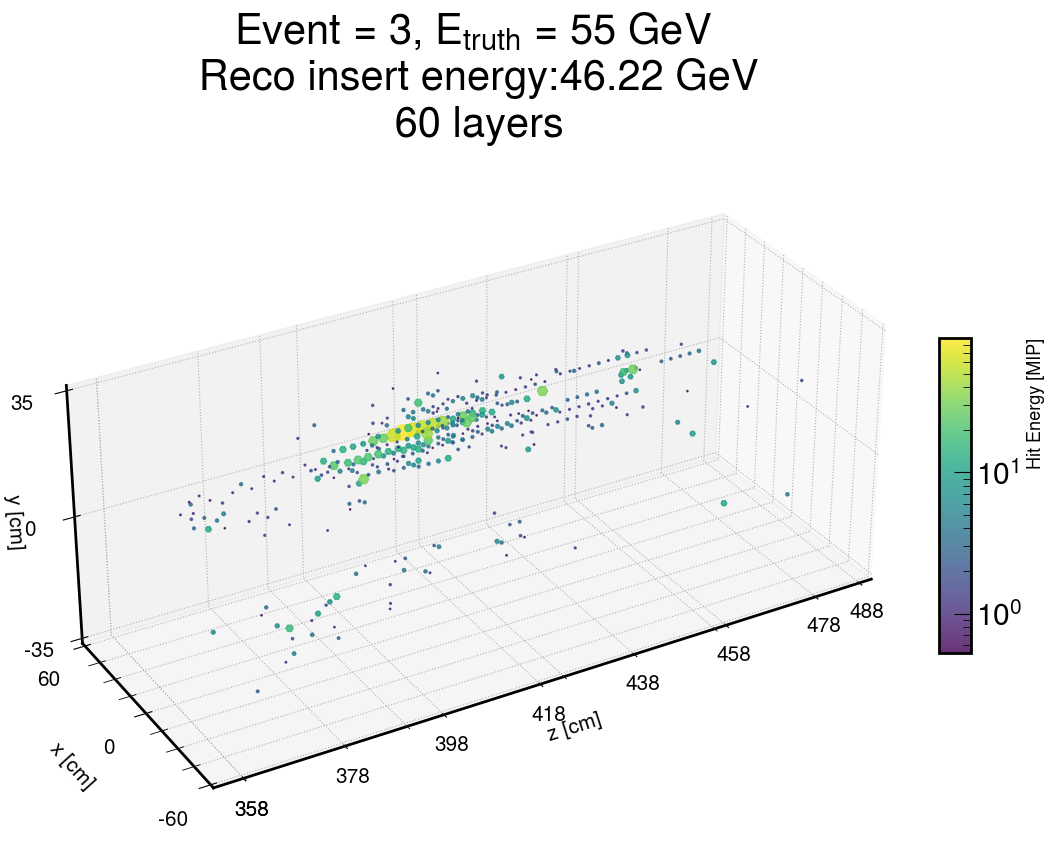

[0.000568, 0.00784, 0.00289, 0.000995, ..., 0.00036, 0.00201, 0.00047, 0.00211]
55.00546362014959
[-10.9, -17.9, -16.2, 10.2, 8.48, -10.9, ..., 3.21, -21.5, -19.7, 3.21, -21.5]
46.22


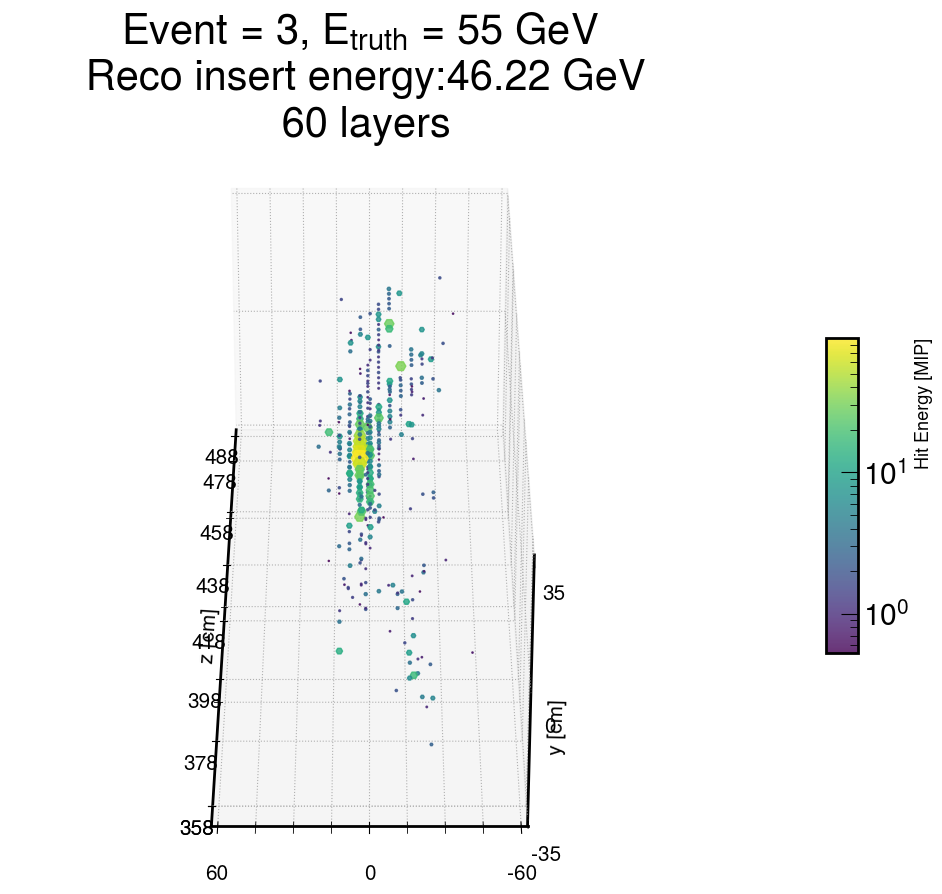

[0.000568, 0.00784, 0.00289, 0.000995, ..., 0.00036, 0.00201, 0.00047, 0.00211]
55.00546362014959
[-10.9, -17.9, -16.2, 10.2, 8.48, -10.9, ..., 3.21, -21.5, -19.7, 3.21, -21.5]
46.22


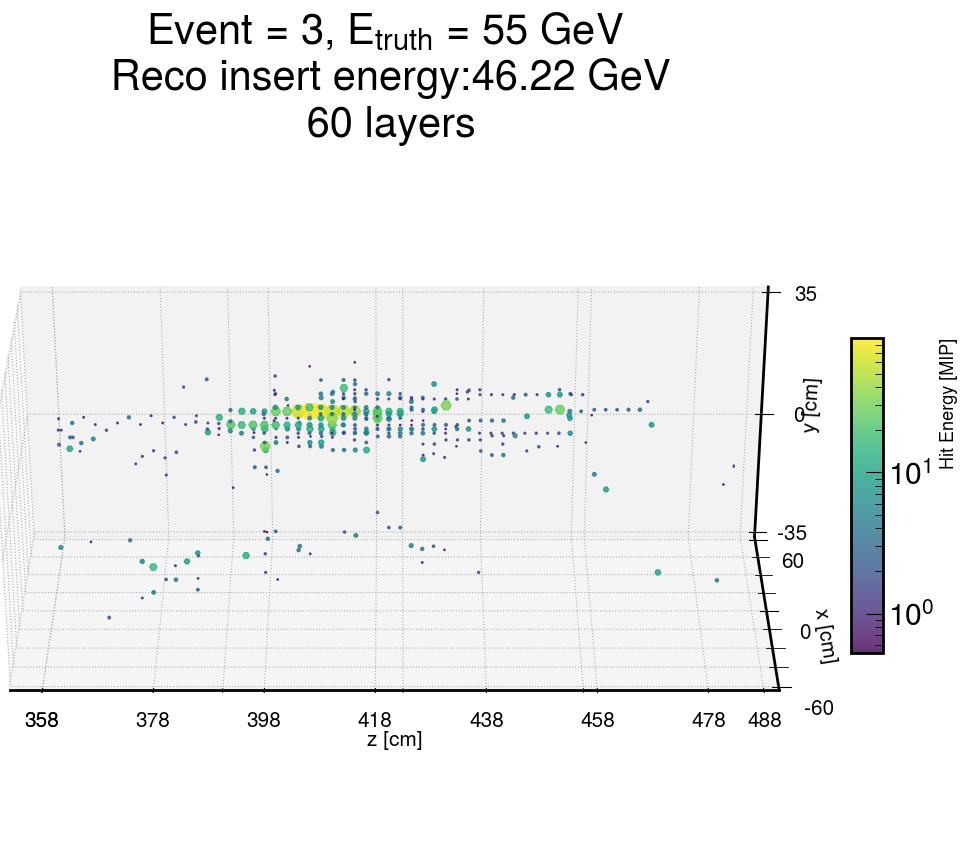

[0.000464, 0.000513, 0.000763, 0.00161, ..., 0.000531, 0.000604, 0.000378]
41.007328955536714
[-26.7, -22.5, -22.5, -22.5, -25, -26.7, ..., -26.7, 1.46, -22.5, -26.7, -21.5]
44.73


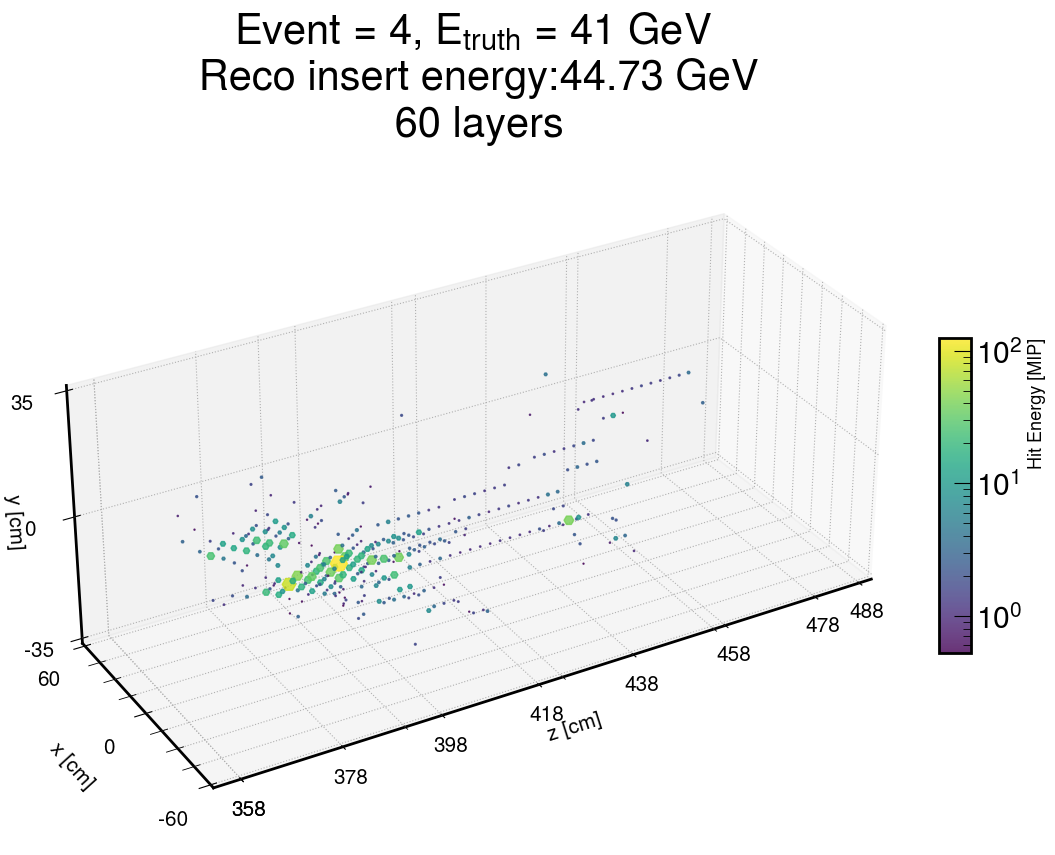

[0.000464, 0.000513, 0.000763, 0.00161, ..., 0.000531, 0.000604, 0.000378]
41.007328955536714
[-26.7, -22.5, -22.5, -22.5, -25, -26.7, ..., -26.7, 1.46, -22.5, -26.7, -21.5]
44.73


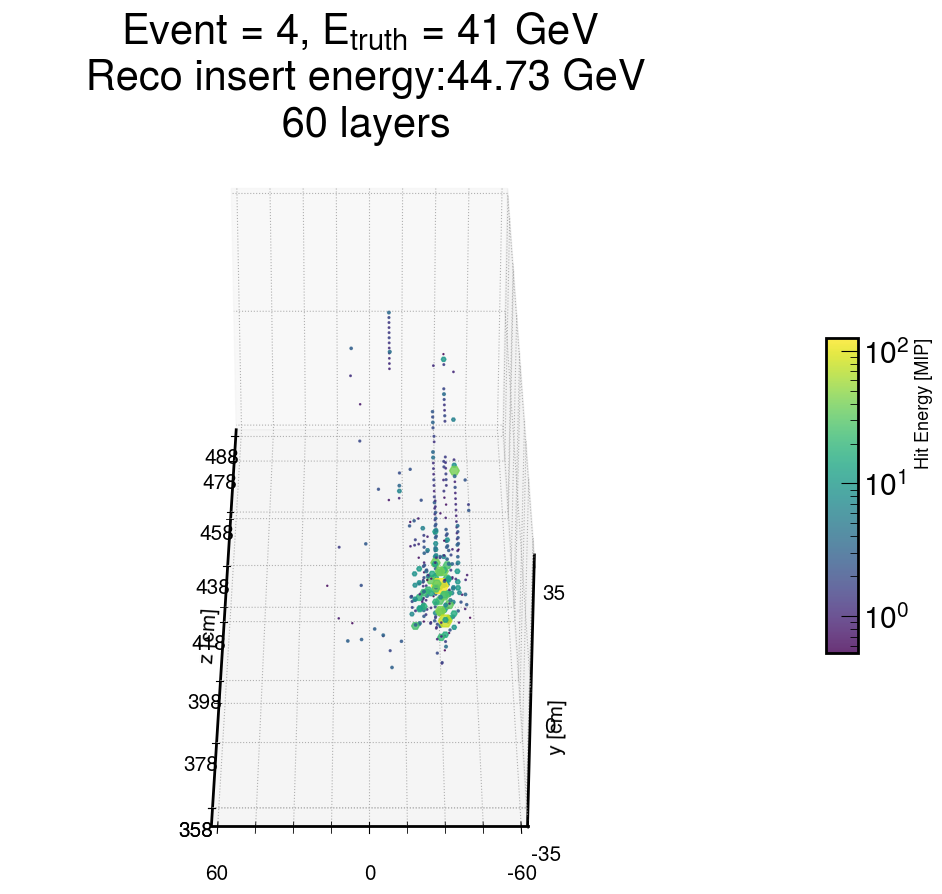

[0.000464, 0.000513, 0.000763, 0.00161, ..., 0.000531, 0.000604, 0.000378]
41.007328955536714
[-26.7, -22.5, -22.5, -22.5, -25, -26.7, ..., -26.7, 1.46, -22.5, -26.7, -21.5]
44.73


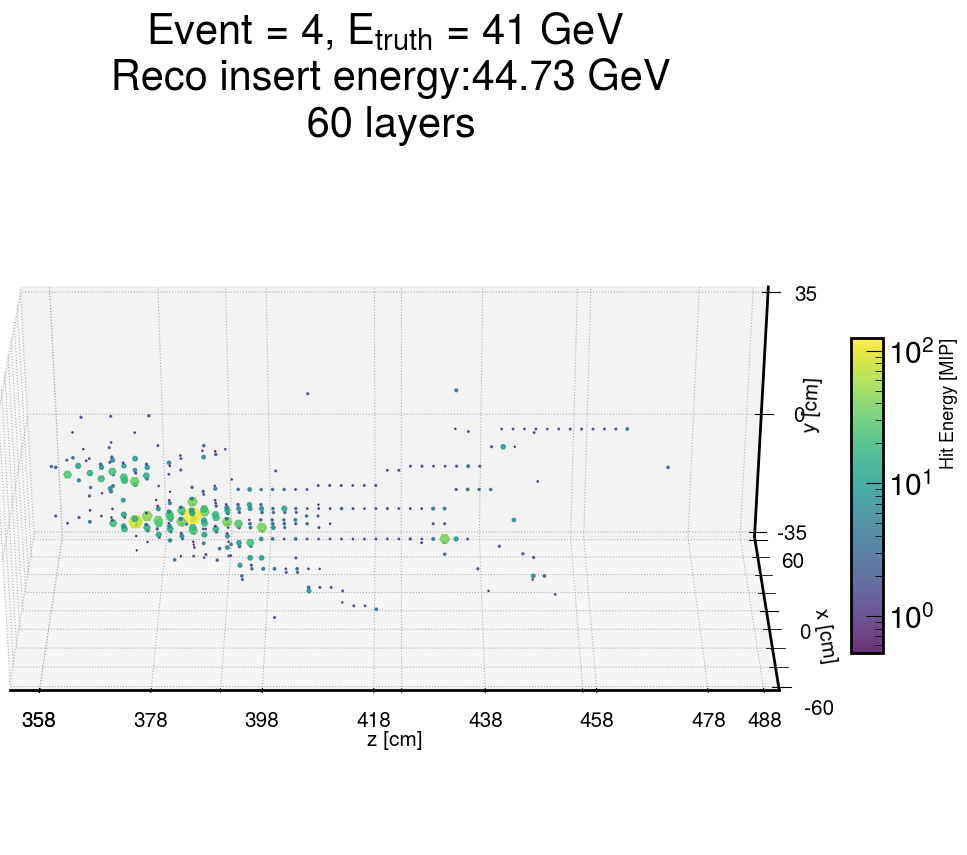

[0.00113, 0.00126, 0.000586, 0.000671, ..., 0.000317, 0.000549, 0.00121]
129.00232954511944
[12.5, 8.23, 8.23, -14.4, -12.7, 8.23, ..., -22.5, -8.59, 8.23, -17.9, -23.2]
27.91


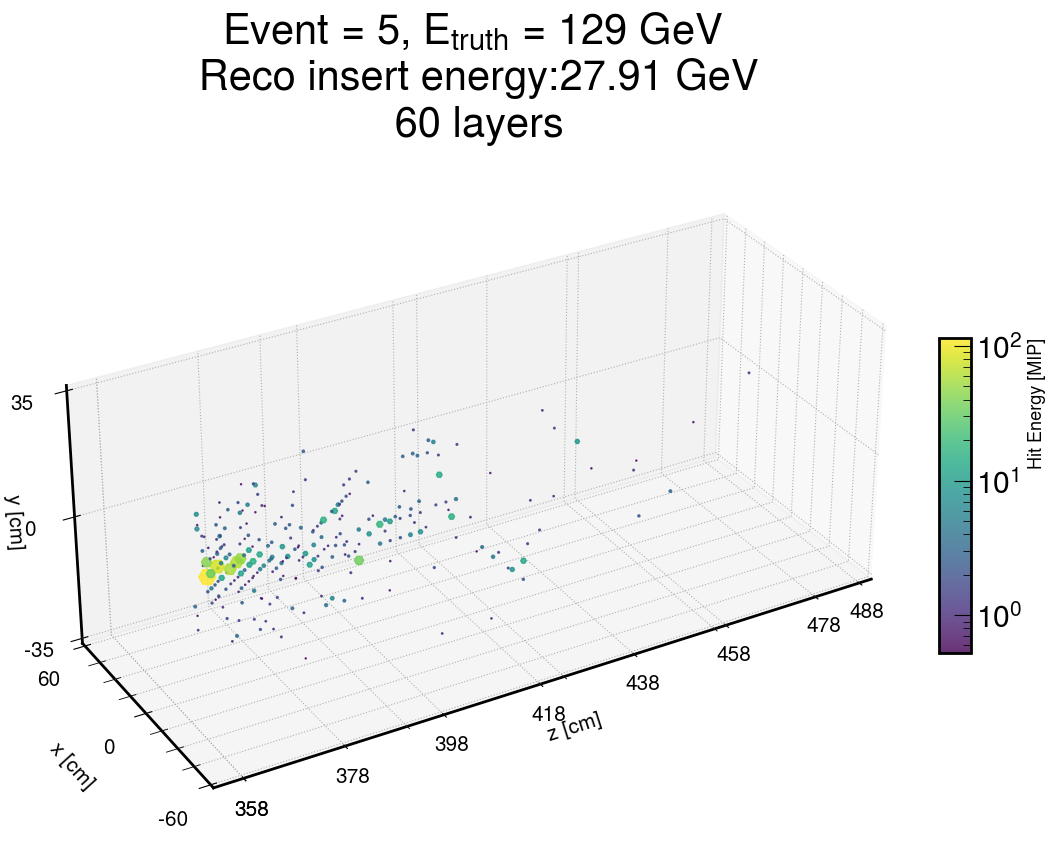

[0.00113, 0.00126, 0.000586, 0.000671, ..., 0.000317, 0.000549, 0.00121]
129.00232954511944
[12.5, 8.23, 8.23, -14.4, -12.7, 8.23, ..., -22.5, -8.59, 8.23, -17.9, -23.2]
27.91


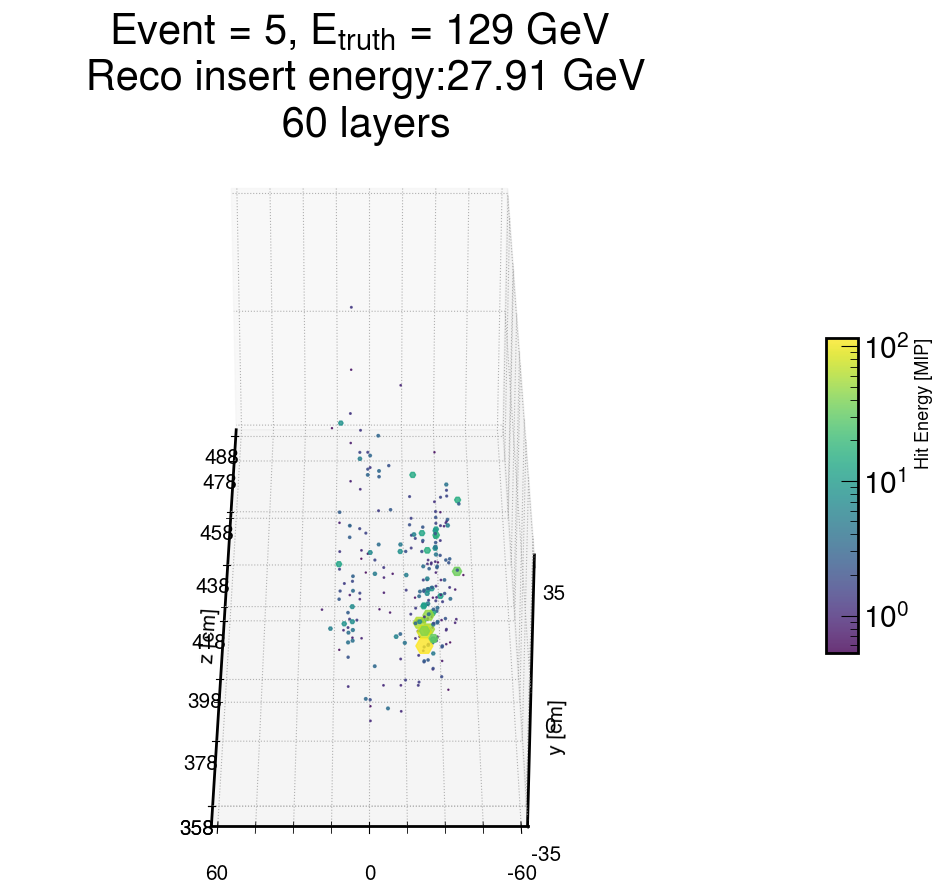

[0.00113, 0.00126, 0.000586, 0.000671, ..., 0.000317, 0.000549, 0.00121]
129.00232954511944
[12.5, 8.23, 8.23, -14.4, -12.7, 8.23, ..., -22.5, -8.59, 8.23, -17.9, -23.2]
27.91


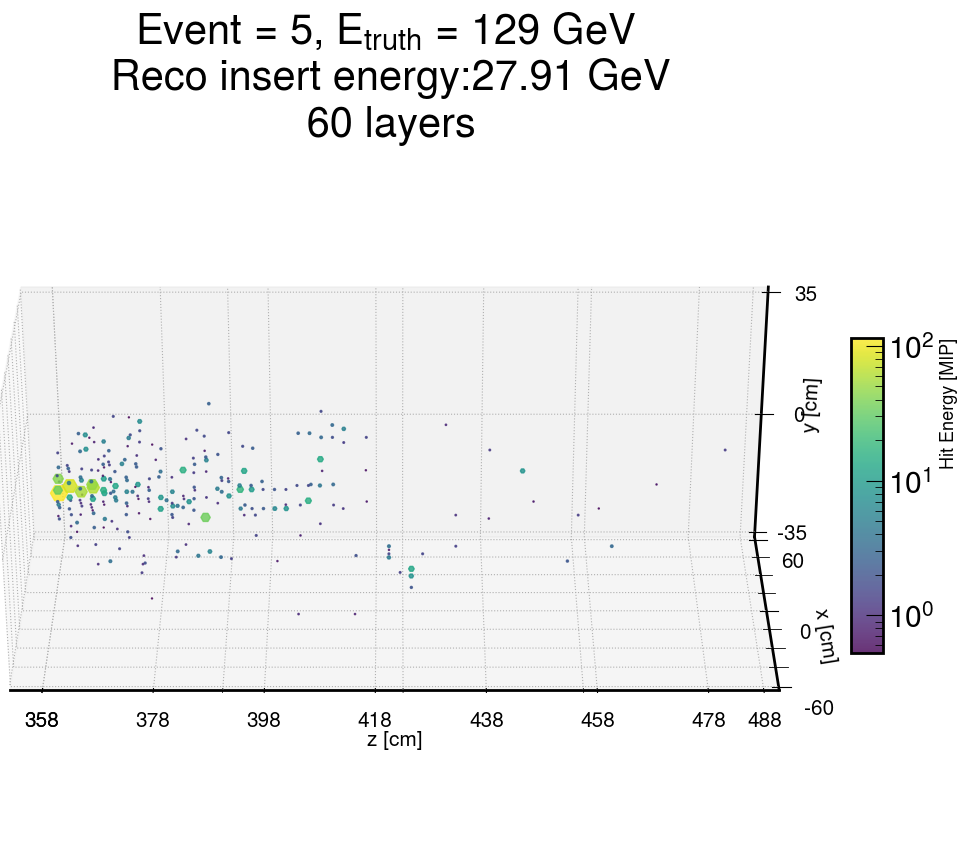

[0.00083, 0.00226, 0.00157, 0.0011, ..., 0.000934, 0.0211, 0.00735, 0.0101]
112.00268312887687
[12.5, 12.5, 8.23, 8.23, 8.23, 8.23, ..., 12.5, -0.395, 3.97, 4.97, 3.21, 6.72]
87.8


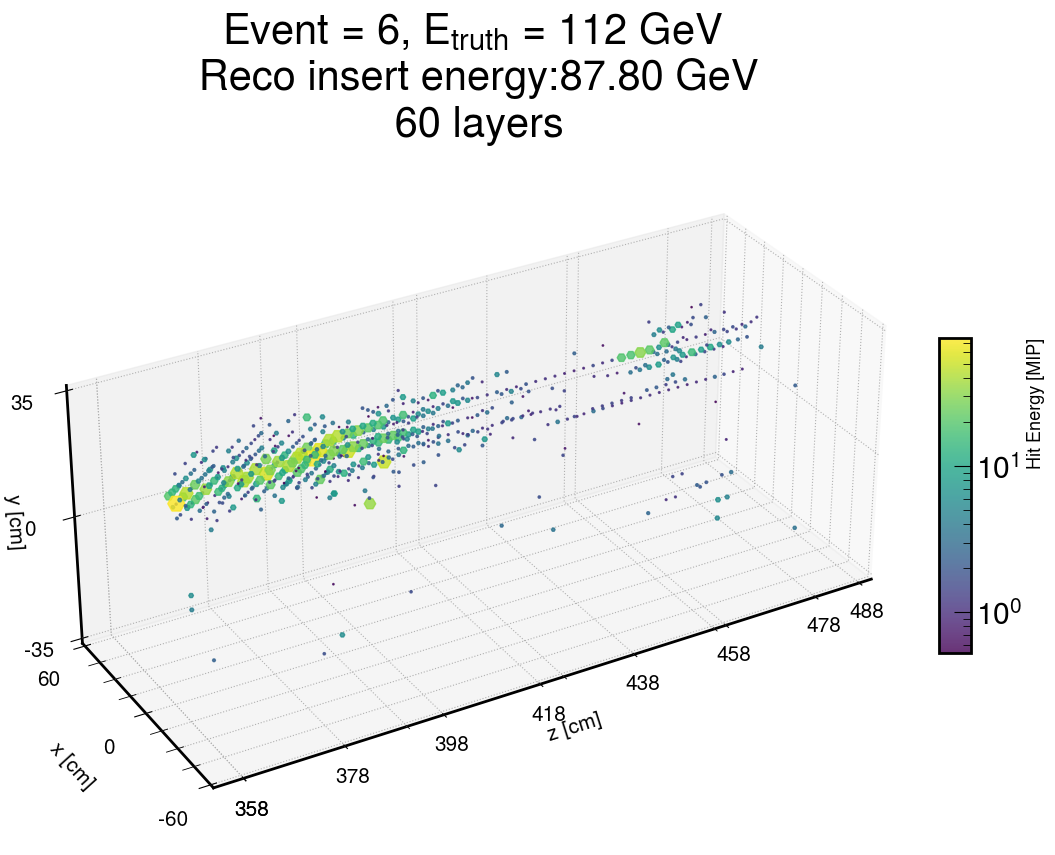

[0.00083, 0.00226, 0.00157, 0.0011, ..., 0.000934, 0.0211, 0.00735, 0.0101]
112.00268312887687
[12.5, 12.5, 8.23, 8.23, 8.23, 8.23, ..., 12.5, -0.395, 3.97, 4.97, 3.21, 6.72]
87.8


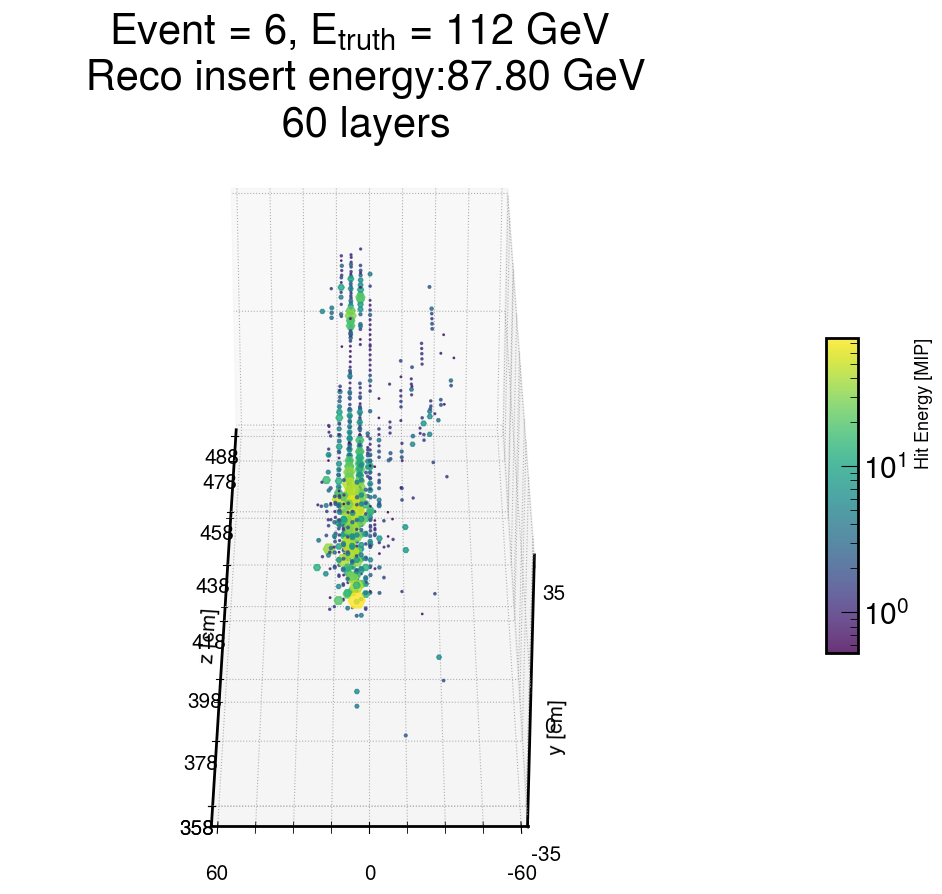

[0.00083, 0.00226, 0.00157, 0.0011, ..., 0.000934, 0.0211, 0.00735, 0.0101]
112.00268312887687
[12.5, 12.5, 8.23, 8.23, 8.23, 8.23, ..., 12.5, -0.395, 3.97, 4.97, 3.21, 6.72]
87.8


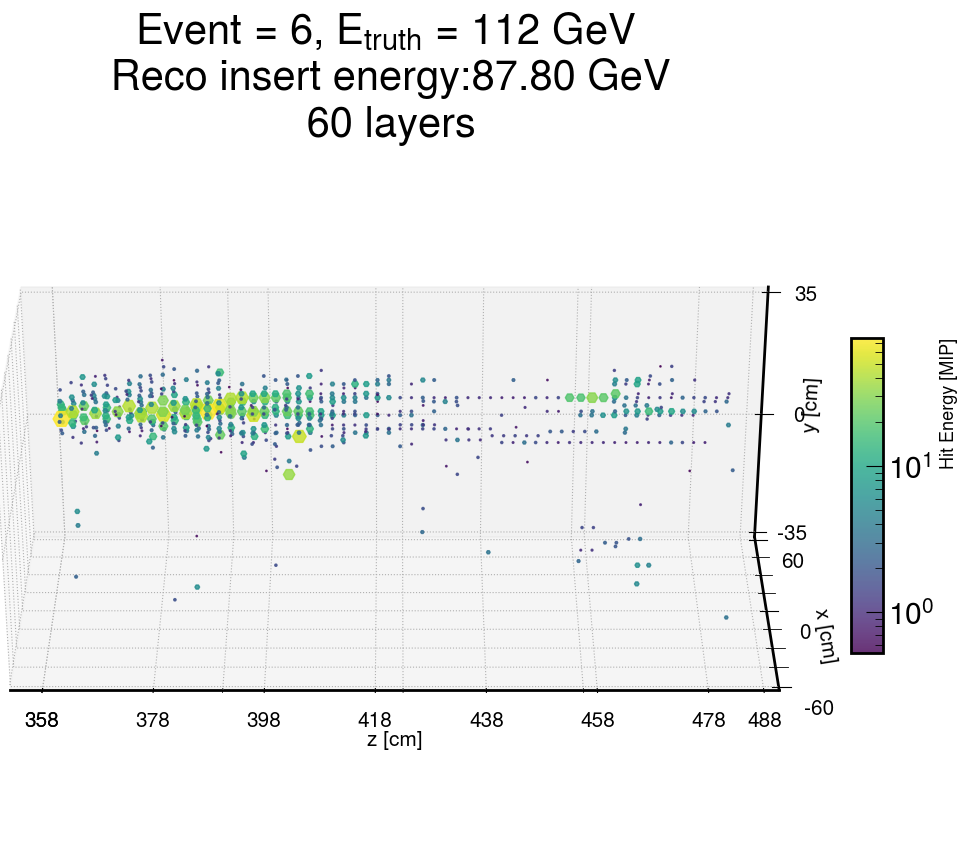

[0.00033, 0.000775, 0.00185, 0.00134, ..., 0.000549, 0.000354, 0.000482]
73.00411651453362
[-22.5, 16.8, -31.8, 8.23, 8.23, -8.59, ..., 12.5, 3.97, 12.5, -3.94, 16.8]
58.02


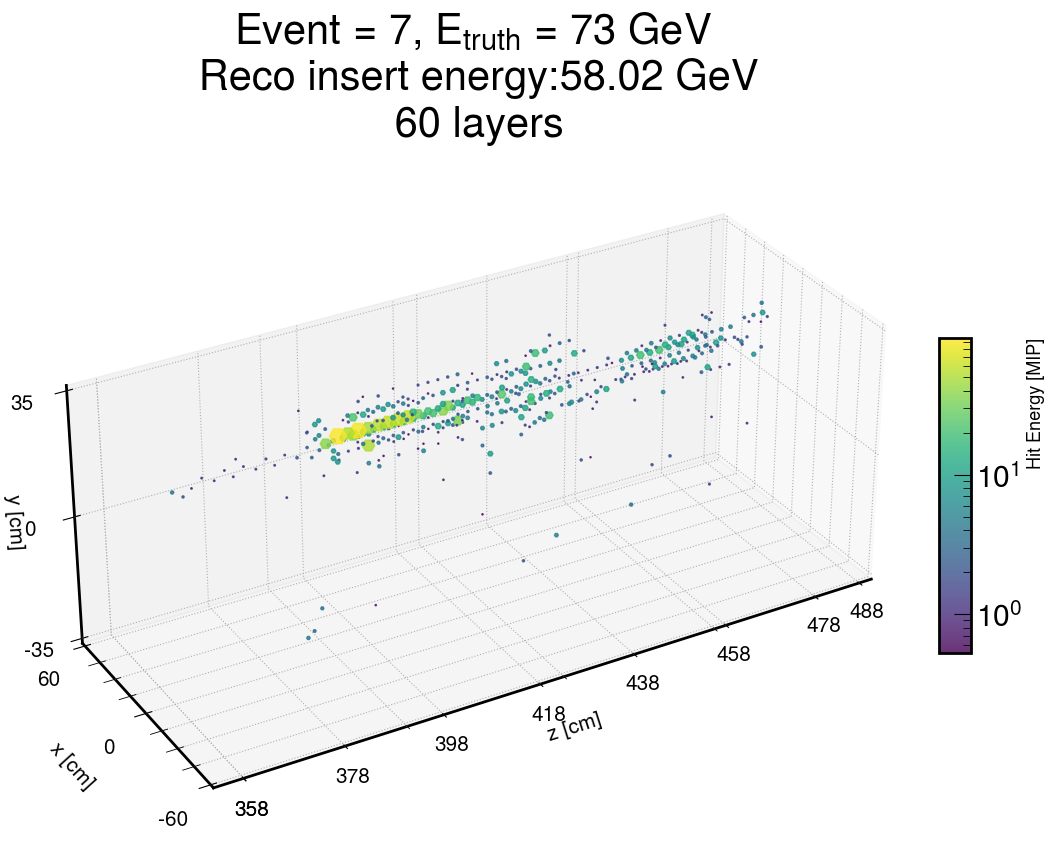

[0.00033, 0.000775, 0.00185, 0.00134, ..., 0.000549, 0.000354, 0.000482]
73.00411651453362
[-22.5, 16.8, -31.8, 8.23, 8.23, -8.59, ..., 12.5, 3.97, 12.5, -3.94, 16.8]
58.02


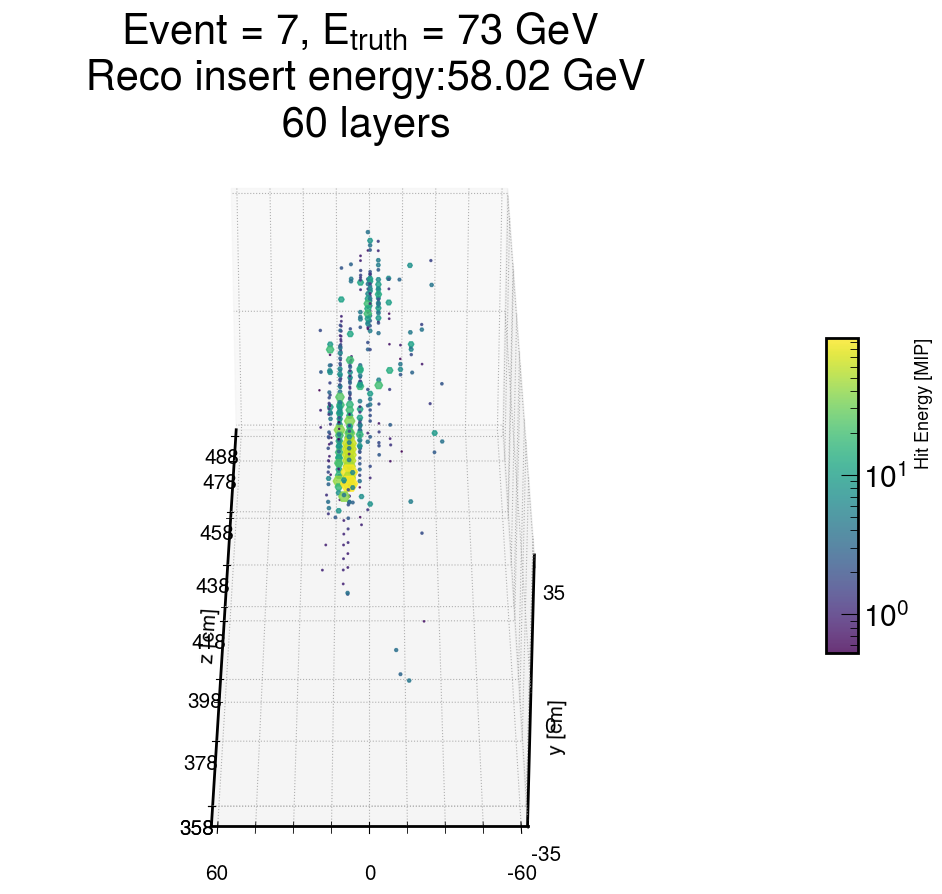

[0.00033, 0.000775, 0.00185, 0.00134, ..., 0.000549, 0.000354, 0.000482]
73.00411651453362
[-22.5, 16.8, -31.8, 8.23, 8.23, -8.59, ..., 12.5, 3.97, 12.5, -3.94, 16.8]
58.02


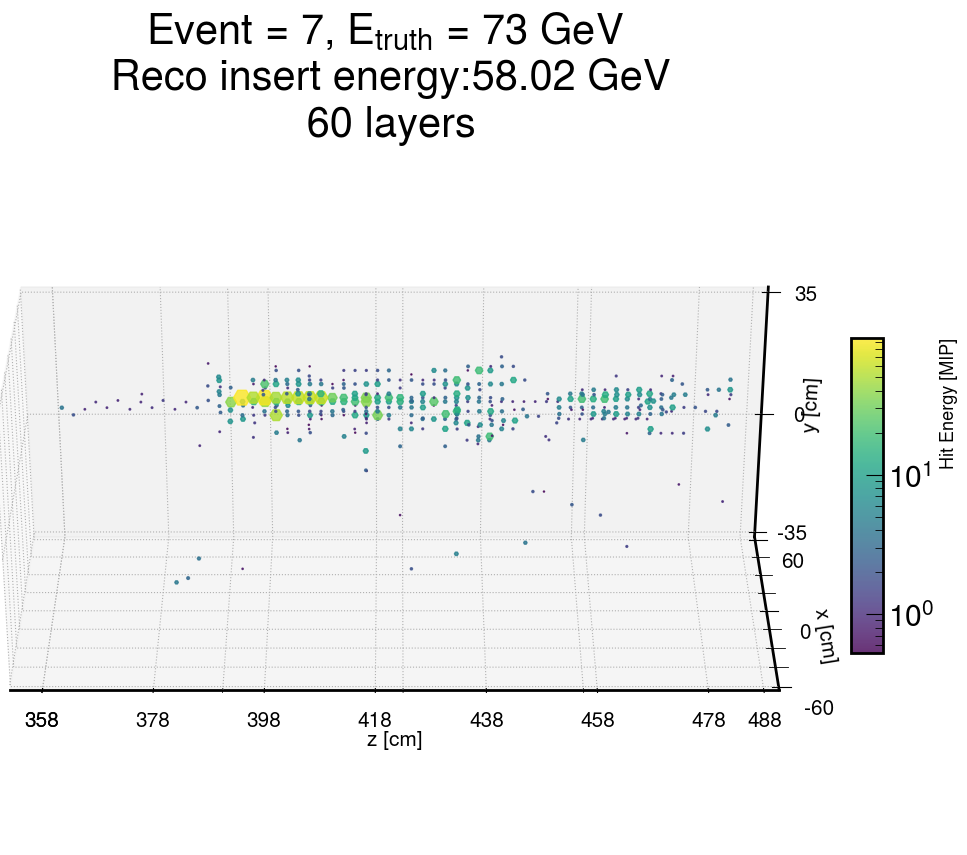

[0.000812, 0.00165, 0.000299, 0.000952, ..., 0.0021, 0.00162, 0.000983, 0.00343]
112.0026831288769
[-31.8, 12, -23.2, 0.71, -22.5, -3.94, ..., -17.9, -17.9, -3.94, -3.94, -3.94]
131.13


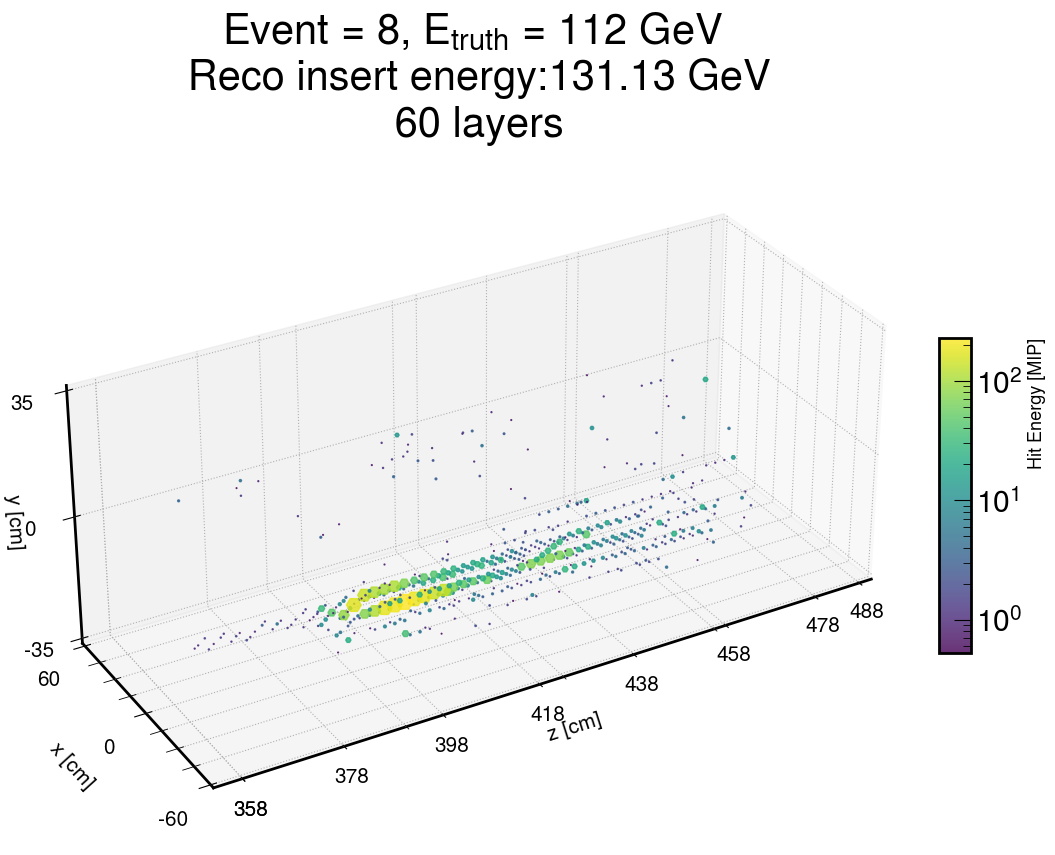

[0.000812, 0.00165, 0.000299, 0.000952, ..., 0.0021, 0.00162, 0.000983, 0.00343]
112.0026831288769
[-31.8, 12, -23.2, 0.71, -22.5, -3.94, ..., -17.9, -17.9, -3.94, -3.94, -3.94]
131.13


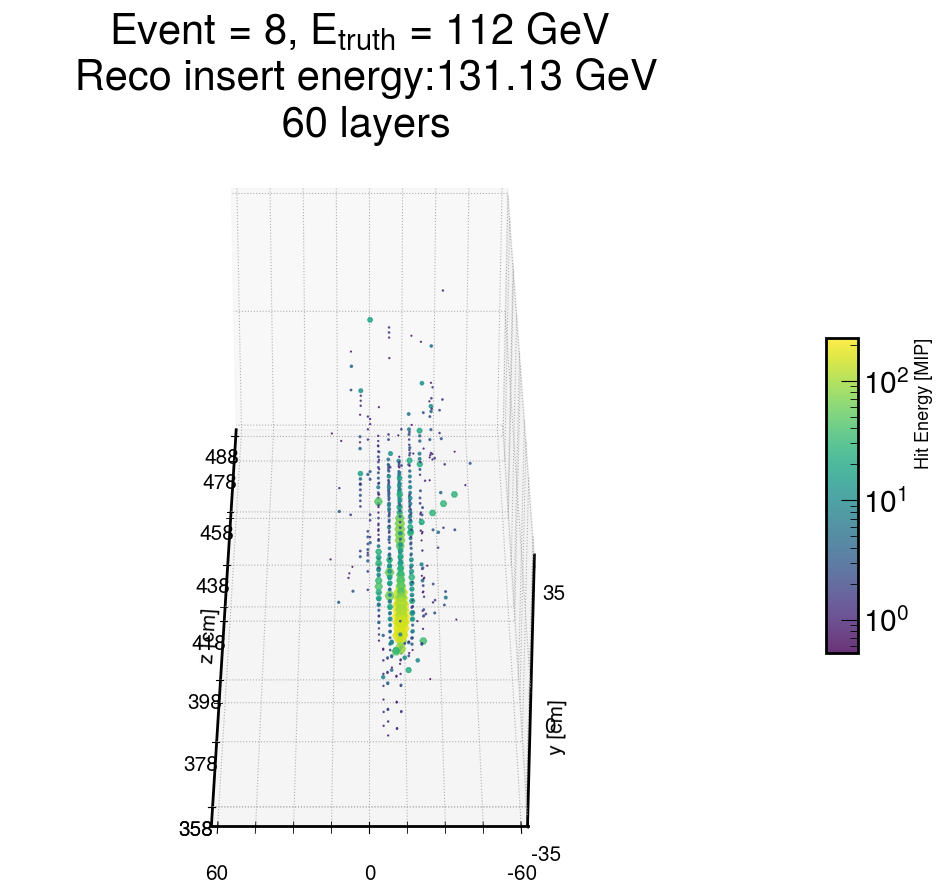

[0.000812, 0.00165, 0.000299, 0.000952, ..., 0.0021, 0.00162, 0.000983, 0.00343]
112.0026831288769
[-31.8, 12, -23.2, 0.71, -22.5, -3.94, ..., -17.9, -17.9, -3.94, -3.94, -3.94]
131.13


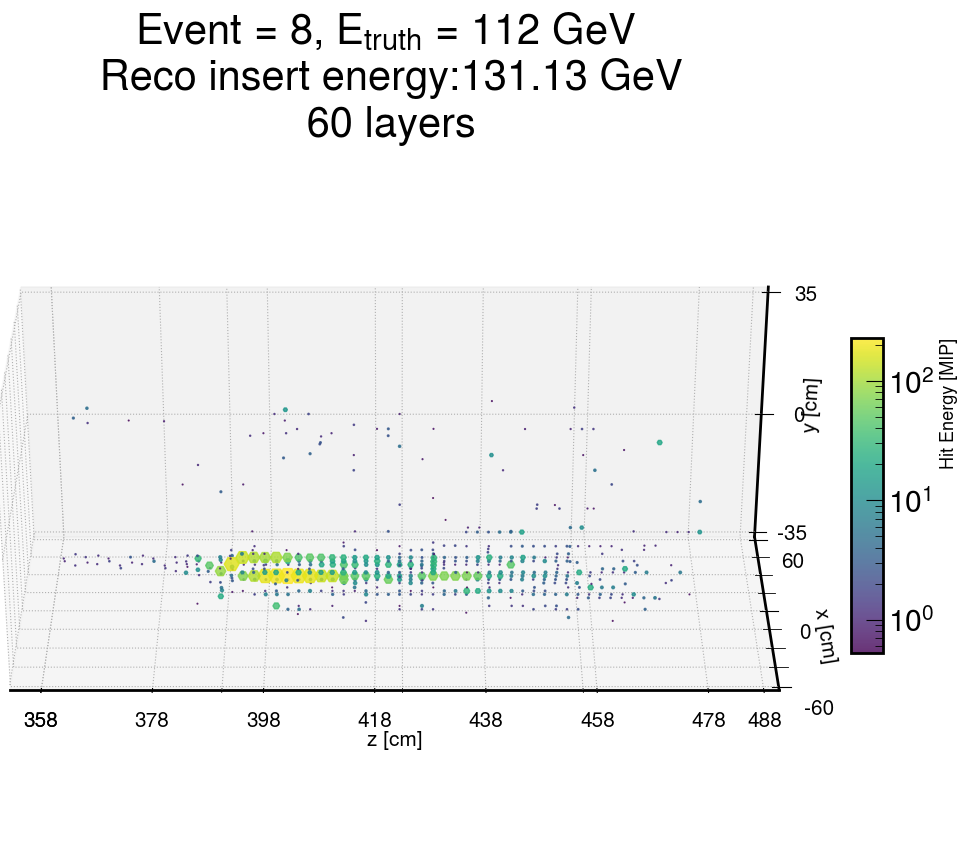

[0.00153, 0.00126, 0.00135, 0.000983, ..., 0.000256, 0.000464, 0.0012, 0.00234]
23.013062118449163
[17.2, 19, 17.2, 17.2, 13.7, 15.5, ..., -7.41, -19.7, -9.17, 17.2, -7.41, -19.7]
14.71


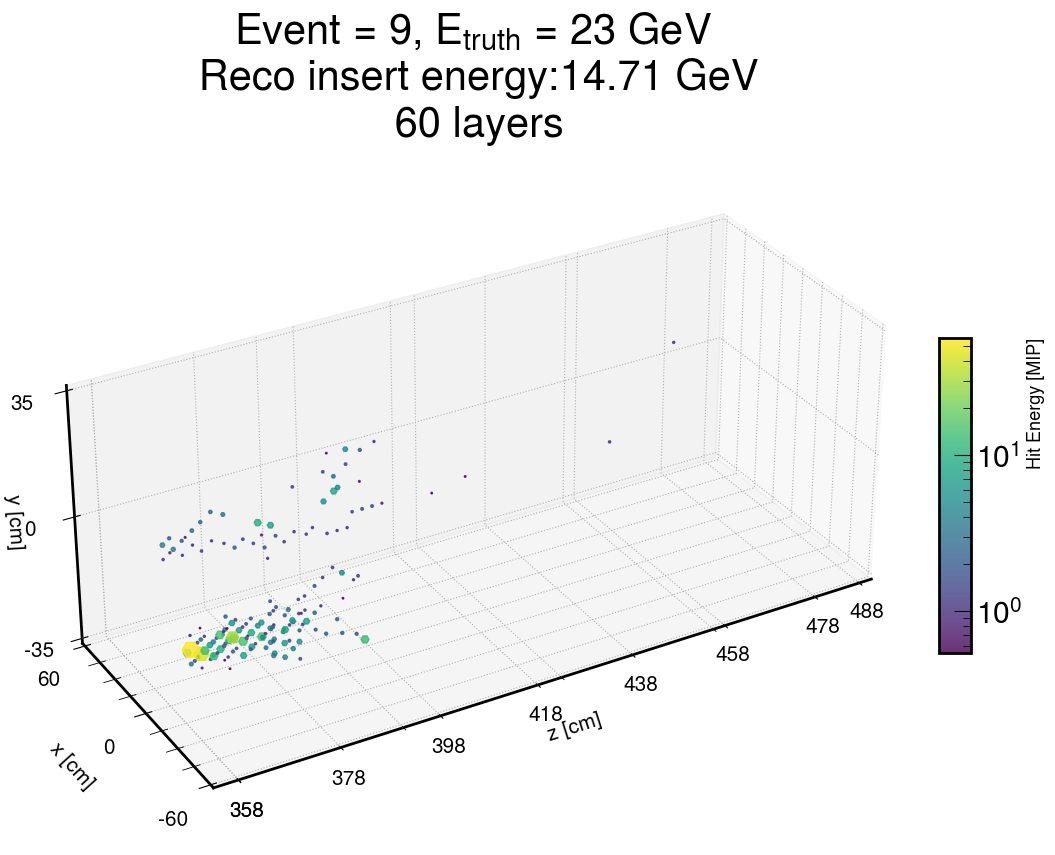

[0.00153, 0.00126, 0.00135, 0.000983, ..., 0.000256, 0.000464, 0.0012, 0.00234]
23.013062118449163
[17.2, 19, 17.2, 17.2, 13.7, 15.5, ..., -7.41, -19.7, -9.17, 17.2, -7.41, -19.7]
14.71


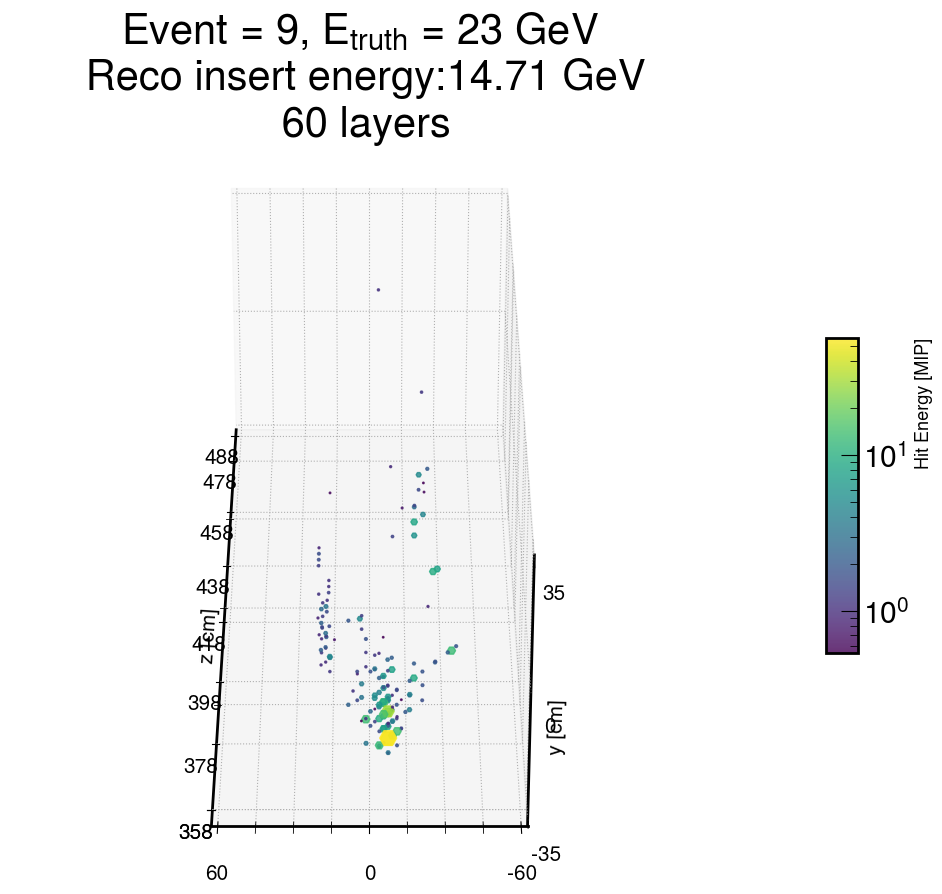

[0.00153, 0.00126, 0.00135, 0.000983, ..., 0.000256, 0.000464, 0.0012, 0.00234]
23.013062118449163
[17.2, 19, 17.2, 17.2, 13.7, 15.5, ..., -7.41, -19.7, -9.17, 17.2, -7.41, -19.7]
14.71


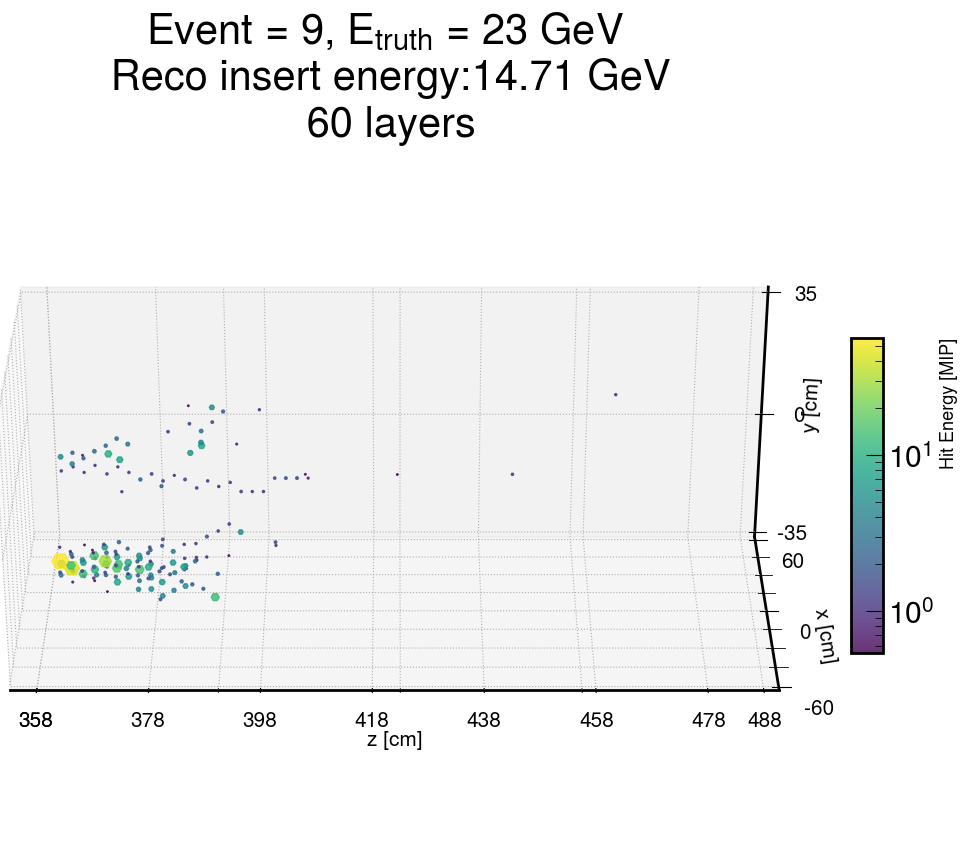

In [33]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
import mplhep as hep
import sys  

hep.style.use("CMS")
#MIP=0.0006
MIP= 0.000472


def get_XYZ_dim(posx, posy, posz):
    x_min=int(np.min(posx))
    x_max=int (np.max(posx))
    
    y_min=int(np.min(posy))
    y_max=int(np.max(posy))
    
    z_min=int(np.min(posz))
    z_max=int(np.max(posz))
    
    return x_min, x_max, y_min, y_max, z_min, z_max
def draw_event(fig, MC, reco, event, azimuthal_angle, num_layers):
    scale_canvas=0.9
        
    MIP_TH=0.5 * 0.0006
    TIME_TH=150.0
    sampling_fraction=0.02
        
    ax1 = fig.add_subplot(211, projection='3d',azim=azimuthal_angle, elev=30)
    
    my_cmap = plt.get_cmap('viridis')
    
    cell_energies = reco["HcalEndcapPInsertRecHits.energy"][event]
    cell_times = reco["HcalEndcapPInsertRecHits.time"][event]
    print(cell_energies)
    nhits=len(cell_energies)

    cell_x=reco["HcalEndcapPInsertRecHits.position.x"][event]/10.
    
    cell_y=reco["HcalEndcapPInsertRecHits.position.y"][event]/10.
    cell_z=reco["HcalEndcapPInsertRecHits.position.z"][event]/10.
    
    final_state_mask = (MC["MCParticles.generatorStatus"]==2) & (MC["MCParticles.PDG"]==113)
    px = MC['MCParticles.momentum.x'][final_state_mask][event]
    py = MC['MCParticles.momentum.y'][final_state_mask][event]
    pz = MC['MCParticles.momentum.z'][final_state_mask][event]
    mass = MC["MCParticles.mass"][final_state_mask][event]

    momentum = np.sqrt(px**2 + py**2 + pz**2)
    energy = np.sqrt(momentum**2 + mass**2)[0]
    print(energy)
    slc=(cell_energies>MIP_TH) & (cell_times<TIME_TH)
    sctt3d = ax1.scatter3D(cell_z, cell_x, cell_y,
                    alpha = 0.8,
                    c = cell_energies/MIP,
                    s=150*cell_energies/np.max(cell_energies),
                    cmap = my_cmap,
                    norm=mpl.colors.LogNorm(),
                    marker ='H')
    
    
    cbar = plt.colorbar(sctt3d, shrink=0.45, pad=0.05, aspect=10)
    cbar.set_label('Hit Energy [MIP]', fontsize=13)
    
    x_min, x_max, y_min, y_max, z_min, z_max=get_XYZ_dim(cell_x, cell_y, cell_z)
    max_val_for_plot=round(np.max([x_max, y_max])/10) *10
    min_y_value, max_y_value = -35, 35
    min_x_value, max_x_value = -60, 60

    print(cell_x)
    plt.ylim(min_x_value,max_x_value) #x
    plt.gca().set_zlim(min_y_value, max_y_value) #y    
    z_ticks = np.arange(min_y_value, max_y_value+1, max_y_value)
    y_ticks = np.arange(min_x_value, max_x_value+1, max_x_value)
    
    ax1.set_zticks(z_ticks)
    ax1.set_yticks(y_ticks)
    specific_values = np.array([358, 488])
   
    x_ticks = np.arange(358, 488, 20)

    x_ticks = np.concatenate([specific_values, x_ticks])
    ax1.set_xticks(x_ticks)
    
    plt.gca().zaxis.labelpad = -2
    strawman_energy = round(ak.sum(cell_energies)/sampling_fraction,2) 
    print(strawman_energy)
    ax1.set_title(f"Event = {event}, $E_{{truth}}$ = {energy:.0f} GeV\n Reco insert energy:{strawman_energy:.2f} GeV\n {num_layers} layers", fontsize=30, pad=-500)
    plt.gca().set_xlabel("\nz [cm]", fontsize=15)
    plt.gca().set_ylabel("\nx [cm]", fontsize=15)
    plt.gca().set_zlabel("y [cm]", fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.gca().zaxis.set_tick_params(labelsize=15)
    
    plt.gca().set_box_aspect((180,70,70), zoom=1.2)
    #plt.show()
    return ax1


start_event = 0
end_event = 10
event_counter = 0
for event_num in range(start_event, end_event):
    if event_counter == (start_event-end_event):
        break
    if len(reco["HcalEndcapPInsertRecHits.energy"][event_num]) == 0:
        continue
    fig=plt.figure( figsize=(30,20))
    draw_event(fig, MC, reco, event_num, azimuthal_angle=-120, num_layers=60)
    plt.show()

    fig=plt.figure( figsize=(30,20))
    draw_event(fig, MC, reco, event_num, azimuthal_angle=-180, num_layers=60)
    plt.show()

    fig=plt.figure( figsize=(30,20))
    draw_event(fig, MC, reco, event_num, azimuthal_angle=-90, num_layers=60)
    plt.show()
    event_counter += 1